# Временные ряды: приведение к стационарному виду

**Домашнее задание к занятию «Знакомство с временными рядами»**

## Постановка задачи

Проанализировать 6 временных рядов из папки `Series` и сделать их стационарными:

1. `monthly-sales-of-company-x-jan-6.csv` — помесячные продажи компании X
2. `monthly-boston-armed-robberies-j.csv` — вооружённые ограбления в Бостоне (помесячно)
3. `international-airline-passengers.csv` — международные авиаперевозки (тыс. пассажиров в месяц)
4. `mean-monthly-air-temperature-deg.csv` — средняя месячная температура воздуха (°F), Ноттингем
5. `weekly-closings-of-the-dowjones-.csv` — недельные закрытия индекса Dow Jones
6. `daily-total-female-births-in-cal.csv` — ежедневное число рождений девочек в Калифорнии

## План работы по каждому ряду

Ряд называется **стационарным**, если его распределение не меняется во времени: постоянны
математическое ожидание, дисперсия и автоковариация (зависит только от лага, но не от момента времени).

Для каждого ряда применяется один и тот же конвейер:

1. **Визуальный анализ** — график ряда, коррелограммы ACF/PACF, сезонная декомпозиция.
2. **Формальные тесты**:
   * **тест Дики–Фуллера (ADF)**: `H0` — в ряде есть единичный корень (ряд **не** стационарен).
     Малое `p-value` (< 0.05) ⇒ гипотезу о нестационарности **отвергаем**;
   * **тест KPSS**: `H0` — ряд стационарен (вокруг константы). Здесь, наоборот, большое `p-value`
     (> 0.05) — в пользу стационарности.

   Два теста используются вместе, потому что у них противоположные нулевые гипотезы: согласованный
   ответ («ADF отвергает `H0`, KPSS не отвергает») — надёжное свидетельство стационарности.
3. **Стабилизация дисперсии** — преобразование Бокса–Кокса (при λ = 0 это обычный логарифм),
   если размах колебаний растёт вместе с уровнем ряда.
4. **Удаление тренда** — дифференцирование первого порядка, `Δy_t = y_t − y_{t−1}`.
5. **Удаление сезонности** — сезонное дифференцирование, `Δ_s y_t = y_t − y_{t−s}`
   (s = 12 для месячных данных, s = 7 для дневных).
6. **Проверка результата** — повторные ADF/KPSS, коррелограммы и тест Льюнга–Бокса.

Важно не «передифференцировать» ряд: каждое лишнее дифференцирование раздувает дисперсию и
добавляет в ряд искусственную MA-компоненту, поэтому останавливаемся, как только ряд стал стационарным.

## 1. Подготовка окружения

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.tsa.api as smt
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import boxcox, boxcox_normmax

warnings.filterwarnings('ignore')
%matplotlib inline

plt.rcParams['figure.figsize'] = (14, 4)
pd.set_option('display.width', 120)

print('pandas      ', pd.__version__)
print('numpy       ', np.__version__)
print('statsmodels ', sm.__version__)

pandas       3.0.5
numpy        2.5.3
statsmodels  0.15.0


### Вспомогательные функции

`test_stationarity` — тест Дики–Фуллера в том же виде, что и в материалах лекции, дополненный тестом KPSS.
`tsplot` — график ряда вместе с коррелограммами ACF/PACF и выводом результатов тестов.

In [2]:
def test_stationarity(timeseries, verbose=True):
    '''Тесты Дики-Фуллера (H0: нестационарен) и KPSS (H0: стационарен).'''
    y = pd.Series(np.asarray(timeseries, dtype=float)).dropna()

    dftest = adfuller(y, autolag='AIC')
    dfoutput = pd.Series(
        dftest[0:4],
        index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'],
    )
    for key, value in dftest[4].items():
        dfoutput['Critical Value (%s)' % key] = value

    kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(y, regression='c', nlags='auto')

    if verbose:
        print('Results of Dickey-Fuller Test:')
        print(dfoutput.to_string())
        print()
        print('Results of KPSS Test:  statistic = %.4f, p-value = %.3f (обрезается в [0.01, 0.10])'
              % (kpss_stat, kpss_p))
        verdict_adf = 'стационарен' if dftest[1] < 0.05 else 'НЕ стационарен'
        verdict_kpss = 'стационарен' if kpss_p > 0.05 else 'НЕ стационарен'
        print('Вывод: ADF -> %s;  KPSS -> %s' % (verdict_adf, verdict_kpss))

    return {'adf_stat': dftest[0], 'adf_p': dftest[1], 'adf_lags': dftest[2],
            'kpss_stat': kpss_stat, 'kpss_p': kpss_p, 'n': len(y)}

In [3]:
def tsplot(y, lags=None, figsize=(14, 9), style='bmh', title='Original'):
    '''График ряда + ACF/PACF + результаты тестов на стационарность.'''
    if not isinstance(y, pd.Series):
        y = pd.Series(y)
    y = y.dropna()

    res = test_stationarity(y)

    # число лагов не должно превышать половины длины ряда
    if lags is None:
        lags = min(40, len(y) // 2 - 1)
    lags = int(min(lags, len(y) // 2 - 1))

    with plt.style.context(style):
        plt.figure(figsize=figsize)
        layout = (4, 1)
        ts_ax = plt.subplot2grid(layout, (0, 0), rowspan=2)
        acf_ax = plt.subplot2grid(layout, (2, 0))
        pacf_ax = plt.subplot2grid(layout, (3, 0))

        y.plot(ax=ts_ax, color='blue')
        ts_ax.set_title('%s   (ADF p-value = %.4g,  KPSS p-value = %.3f)'
                        % (title, res['adf_p'], res['kpss_p']))

        smt.graphics.plot_acf(y, lags=lags, ax=acf_ax, alpha=0.05)
        smt.graphics.plot_pacf(y, lags=lags, ax=pacf_ax, alpha=0.05, method='ywm')

        plt.tight_layout()
        plt.show()

    return res

In [4]:
def plot_decomposition(y, period, title='', model='additive'):
    '''Разложение ряда на тренд, сезонность и остаток.'''
    decomposition = seasonal_decompose(y, model=model, period=period)
    with plt.style.context('bmh'):
        fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=True)
        decomposition.observed.plot(ax=axes[0], color='blue');  axes[0].set_ylabel('Исходный')
        decomposition.trend.plot(ax=axes[1], color='darkred');  axes[1].set_ylabel('Тренд')
        decomposition.seasonal.plot(ax=axes[2], color='green'); axes[2].set_ylabel('Сезонность')
        decomposition.resid.plot(ax=axes[3], color='gray', marker='.', linestyle='none')
        axes[3].set_ylabel('Остаток')
        axes[0].set_title('Сезонная декомпозиция: %s (период = %d)' % (title, period))
        plt.tight_layout()
        plt.show()
    return decomposition


def ljung_box(y, lags=(10, 20)):
    '''Тест Льюнга-Бокса: H0 - автокорреляции до указанного лага равны нулю (белый шум).'''
    y = pd.Series(np.asarray(y, dtype=float)).dropna()
    lags = [l for l in lags if l < len(y) // 2]
    out = acorr_ljungbox(y, lags=lags, return_df=True)
    print('Тест Льюнга-Бокса (H0: автокорреляций нет):')
    print(out.to_string())
    return out


def seasonal_profile(y, period, title=''):
    '''Средние значения по позиции внутри сезонного цикла - наглядная проверка сезонности.'''
    pos = np.arange(len(y)) % period
    profile = pd.Series(np.asarray(y, dtype=float)).groupby(pos).mean()
    with plt.style.context('bmh'):
        plt.figure(figsize=(14, 3))
        profile.plot(kind='bar', color='steelblue')
        plt.title('Средний профиль сезонного цикла: %s (период = %d)' % (title, period))
        plt.xlabel('позиция внутри цикла')
        plt.tight_layout()
        plt.show()
    return profile

## 2. Загрузка данных

Во всех файлах два столбца: метка времени и значение. Отдельного внимания требует Dow Jones —
там метка вида `1971-W27` (ISO-неделя), её разбираем форматом `%G-W%V-%u`, подставляя
понедельник (`-1`) как день недели.

In [5]:
DATA_DIR = 'Series'

sales_of_company_x  = pd.read_csv(f'{DATA_DIR}/monthly-sales-of-company-x-jan-6.csv')
robberies_in_boston = pd.read_csv(f'{DATA_DIR}/monthly-boston-armed-robberies-j.csv')
airline_passengers  = pd.read_csv(f'{DATA_DIR}/international-airline-passengers.csv')
mean_monthly_temp   = pd.read_csv(f'{DATA_DIR}/mean-monthly-air-temperature-deg.csv')
dowjones_closing    = pd.read_csv(f'{DATA_DIR}/weekly-closings-of-the-dowjones-.csv')
female_births       = pd.read_csv(f'{DATA_DIR}/daily-total-female-births-in-cal.csv')

for name, df in [('sales', sales_of_company_x), ('robberies', robberies_in_boston),
                 ('airline', airline_passengers), ('temperature', mean_monthly_temp),
                 ('dowjones', dowjones_closing), ('births', female_births)]:
    print(f'{name:12s} shape={df.shape}  columns={list(df.columns)}  '
          f'range: {df.iloc[0, 0]} .. {df.iloc[-1, 0]}  NaN: {int(df.isna().sum().sum())}')

sales        shape=(77, 2)  columns=['Month', 'Count']  range: 1965-01 .. 1971-05  NaN: 0
robberies    shape=(118, 2)  columns=['Month', 'Count']  range: 1966-01 .. 1975-10  NaN: 0
airline      shape=(144, 2)  columns=['Month', 'Count']  range: 1949-01 .. 1960-12  NaN: 0
temperature  shape=(240, 2)  columns=['Month', 'Deg']  range: 1920-01 .. 1939-12  NaN: 0
dowjones     shape=(162, 2)  columns=['Week', 'Close']  range: 1971-W27 .. 1974-W32  NaN: 0
births       shape=(365, 2)  columns=['Date', 'Count']  range: 1959-01-01 .. 1959-12-31  NaN: 0


In [6]:
def to_series(df, time_col, value_col, freq):
    '''Превращаем DataFrame в pd.Series с корректным DatetimeIndex.'''
    if freq == 'W':
        idx = pd.to_datetime(df[time_col] + '-1', format='%G-W%V-%u')
    else:
        idx = pd.to_datetime(df[time_col])
    s = pd.Series(df[value_col].astype(float).values, index=idx)
    return s.asfreq(pd.infer_freq(idx)) if freq != 'W' else s.asfreq('W-MON')


sales       = to_series(sales_of_company_x,  'Month', 'Count', 'MS')
robberies   = to_series(robberies_in_boston, 'Month', 'Count', 'MS')
airline     = to_series(airline_passengers,  'Month', 'Count', 'MS')
temperature = to_series(mean_monthly_temp,   'Month', 'Deg',   'MS')
dowjones    = to_series(dowjones_closing,    'Week',  'Close', 'W')
births      = to_series(female_births,       'Date',  'Count', 'D')

all_series = {
    'Monthly sales of company X': sales,
    'Monthly Boston armed robberies': robberies,
    'International airline passengers (thousands)': airline,
    'Mean monthly air temperature (Deg. F), Nottingham Castle': temperature,
    'Weekly closings of the Dow-Jones industrial average': dowjones,
    'Daily total female births in California': births,
}

summary = pd.DataFrame(
    [{'Ряд': k, 'N': len(v), 'Начало': v.index[0].date(), 'Конец': v.index[-1].date(),
      'Частота': v.index.freqstr, 'Пропуски': int(v.isna().sum()),
      'min': round(v.min(), 2), 'mean': round(v.mean(), 2), 'max': round(v.max(), 2)}
     for k, v in all_series.items()]
)
summary

,Ряд,N,Начало,Конец,Частота,Пропуски,min,mean,max
0,Monthly sales of company X,77,1965-01-01,1971-05-01,MS,0,36.00,298.40,895.00
1,Monthly Boston armed robberies,118,1966-01-01,1975-10-01,MS,0,29.00,196.29,500.00
2,International airline passengers (thousands),144,1949-01-01,1960-12-01,MS,0,104.00,280.30,622.00
3,"Mean monthly air temperature (Deg. F), Notting...",240,1920-01-01,1939-12-01,MS,0,31.30,49.04,66.50
4,Weekly closings of the Dow-Jones industrial av...,162,1971-07-05,1974-08-05,W-MON,0,752.58,907.48,1047.49
5,Daily total female births in California,365,1959-01-01,1959-12-31,D,0,23.00,41.98,73.00


Пропусков нет ни в одном ряду, частоты определились корректно — можно работать дальше.

### Общий взгляд на все шесть рядов

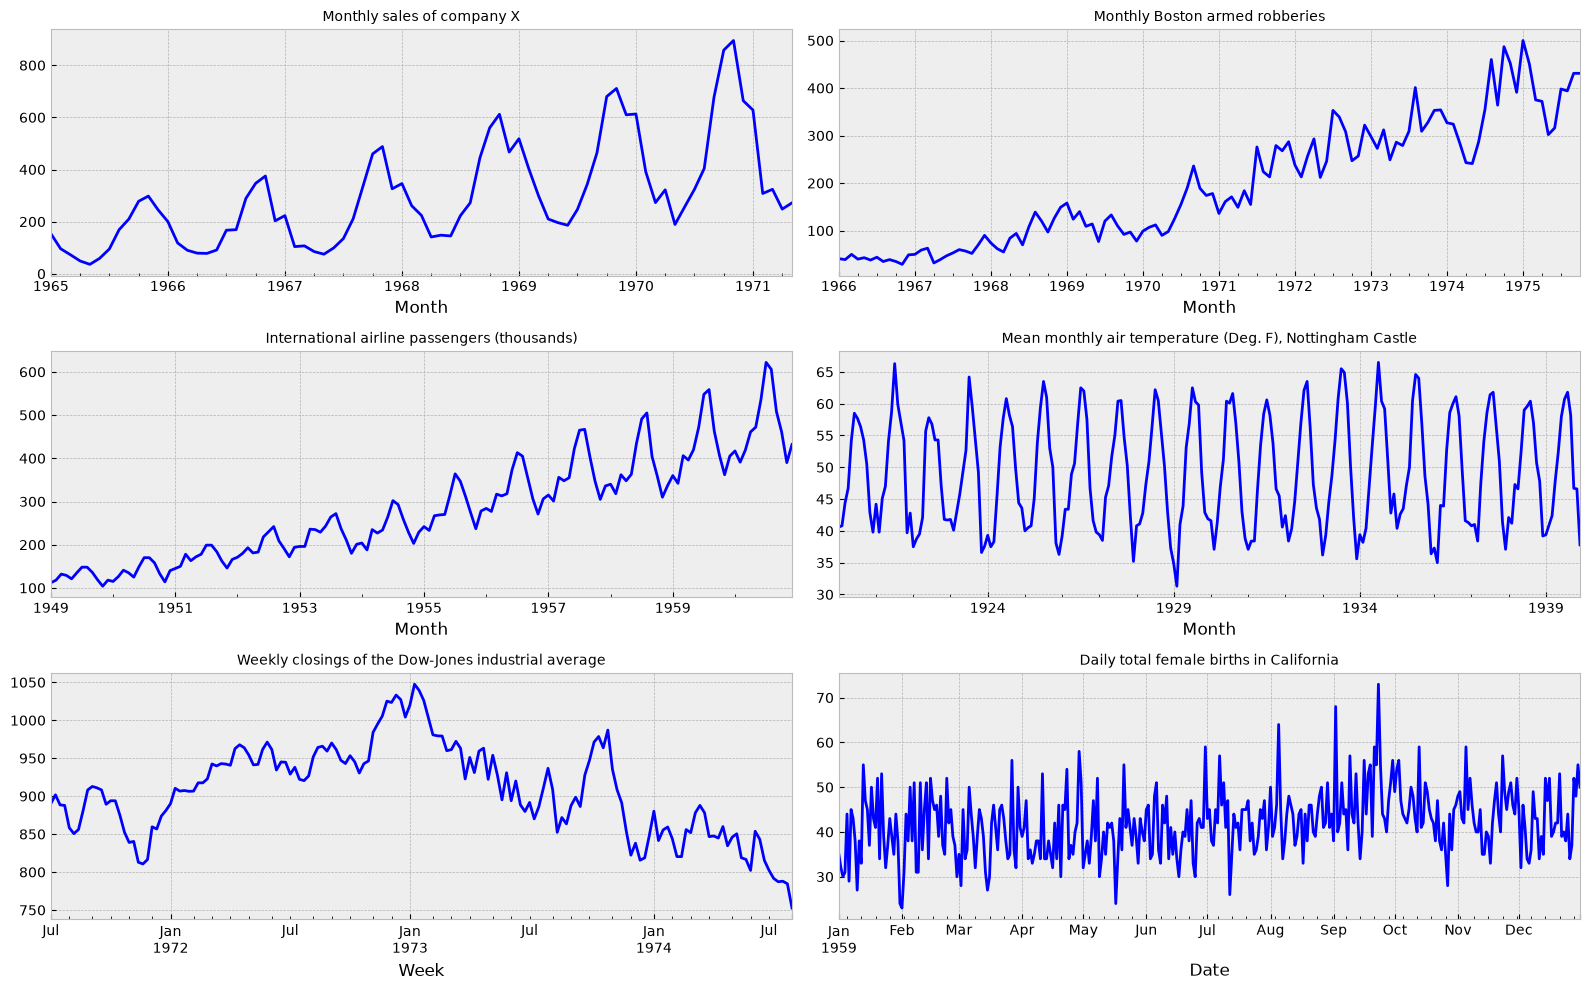

In [7]:
with plt.style.context('bmh'):
    plt.figure(figsize=(16, 10))
    layout = (3, 2)
    for i, (key, ts) in enumerate(all_series.items()):
        x = i % 2
        y = (i - x) // 2
        ts_ax = plt.subplot2grid(layout, (y, x))
        ts.plot(ax=ts_ax, color='blue')
        ts_ax.set_title(key, fontsize=10)
    plt.tight_layout()
    plt.show()

Уже по графикам видно, что все шесть рядов ведут себя по-разному:

| Ряд | Тренд | Сезонность | Растущая дисперсия |
|---|---|---|---|
| Sales of company X | есть | есть (годовая) | есть |
| Boston armed robberies | сильный | слабая | есть |
| Airline passengers | сильный | ярко выраженная | есть |
| Air temperature | нет | ярко выраженная, стабильная амплитуда | нет |
| Dow Jones | блуждание (стохастический тренд) | нет | нет |
| Female births | почти нет | недельная (период 7) | нет |

Значит и «рецепт» приведения к стационарности для каждого ряда будет свой.
Заведём словарь, куда будем складывать итоги.

In [8]:
results = {}   # сюда соберём итоговые преобразования и p-value тестов

def remember(name, raw, stationary, recipe):
    results[name] = {'Ряд': name, 'Преобразование': recipe,
                     'N (итог)': len(stationary.dropna()),
                     'ADF p (исходный)': raw['adf_p'], 'KPSS p (исходный)': raw['kpss_p']}
    res = test_stationarity(stationary, verbose=False)
    results[name]['ADF p (итог)'] = res['adf_p']
    results[name]['KPSS p (итог)'] = res['kpss_p']
    return res

---
# Ряд 1. Monthly sales of company X

Помесячные продажи компании X, январь 1965 — май 1971, 77 наблюдений.

### 1.1. Исходный ряд

Results of Dickey-Fuller Test:
Test Statistic                  0.654715
p-value                         0.988889
#Lags Used                     12.000000
Number of Observations Used    64.000000
Critical Value (1%)            -3.536928
Critical Value (5%)            -2.907887
Critical Value (10%)           -2.591493

Results of KPSS Test:  statistic = 0.8524, p-value = 0.010 (обрезается в [0.01, 0.10])
Вывод: ADF -> НЕ стационарен;  KPSS -> НЕ стационарен


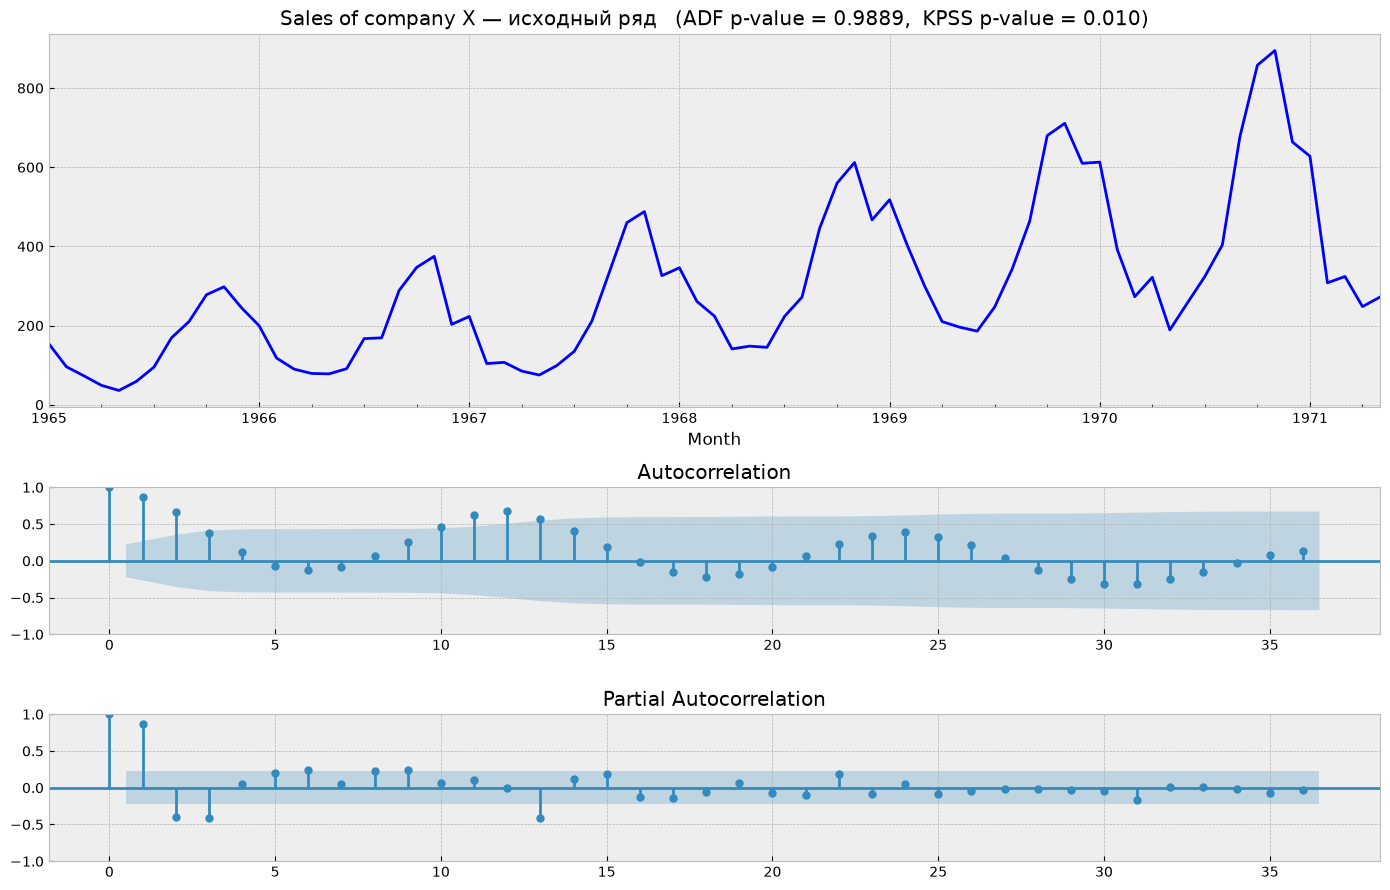

In [9]:
sales_raw_res = tsplot(sales, lags=36, title='Sales of company X — исходный ряд')

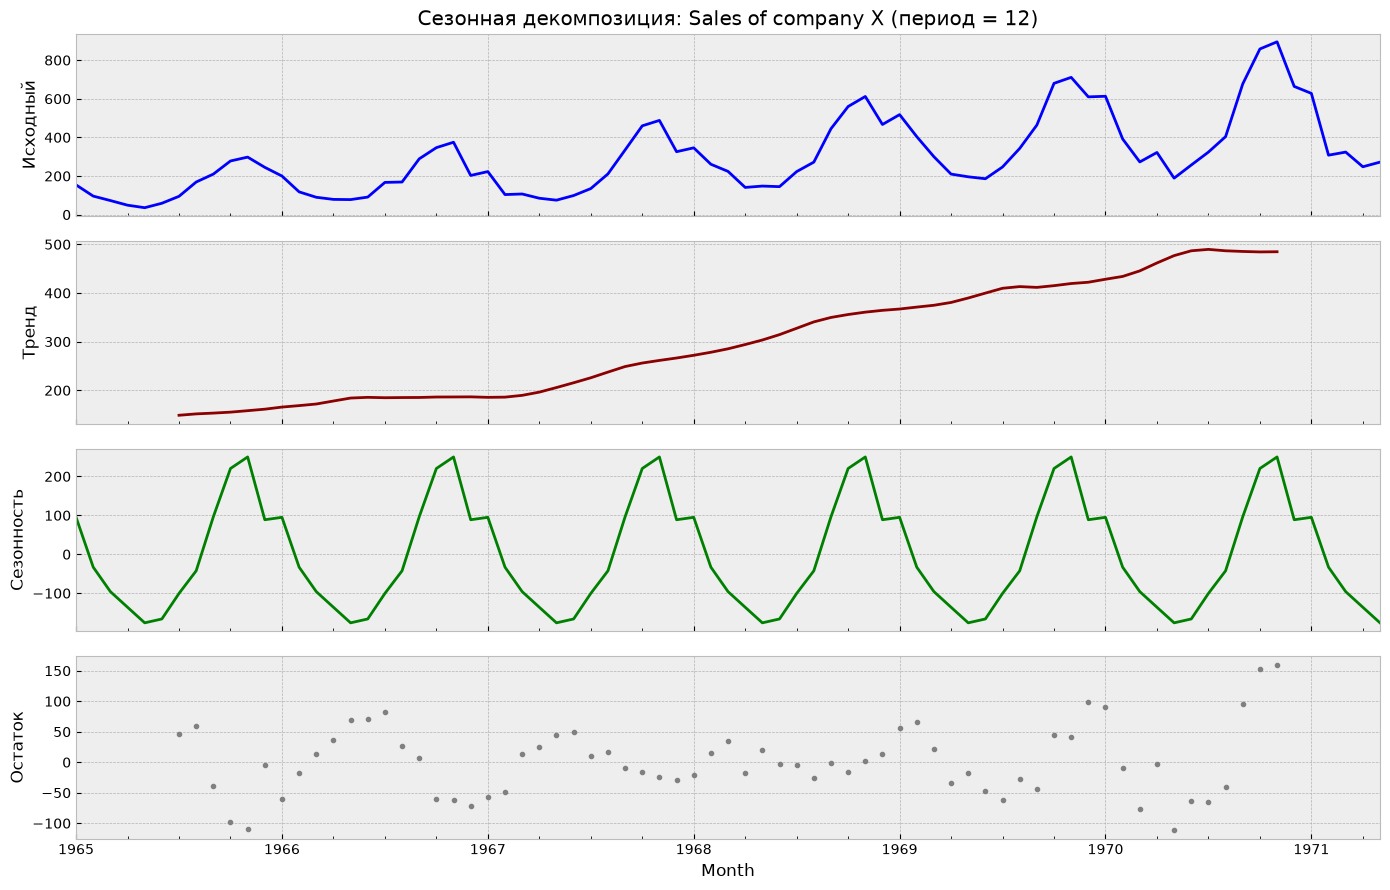

In [10]:
plot_decomposition(sales, period=12, title='Sales of company X');

**Что видим.** ADF `p-value ≈ 0.99` — гипотезу о нестационарности не отвергаем. Автокорреляционная
функция затухает крайне медленно (признак тренда/единичного корня), а на лагах 12 и 24 видны
локальные «горбы» — годовая сезонность. Декомпозиция подтверждает: есть и растущий тренд,
и устойчивая годовая волна. Амплитуда колебаний к концу ряда заметно больше, чем в начале,
то есть дисперсия непостоянна.

**Шаг 1 — стабилизируем дисперсию** преобразованием Бокса–Кокса.

Оптимальное λ по Боксу-Коксу: 0.223
λ заметно меньше 1 => преобразование действительно нужно; берём λ = 0 (логарифм) как наиболее интерпретируемое.
Results of Dickey-Fuller Test:
Test Statistic                 -0.908049
p-value                         0.785310
#Lags Used                     12.000000
Number of Observations Used    64.000000
Critical Value (1%)            -3.536928
Critical Value (5%)            -2.907887
Critical Value (10%)           -2.591493

Results of KPSS Test:  statistic = 0.9101, p-value = 0.010 (обрезается в [0.01, 0.10])
Вывод: ADF -> НЕ стационарен;  KPSS -> НЕ стационарен


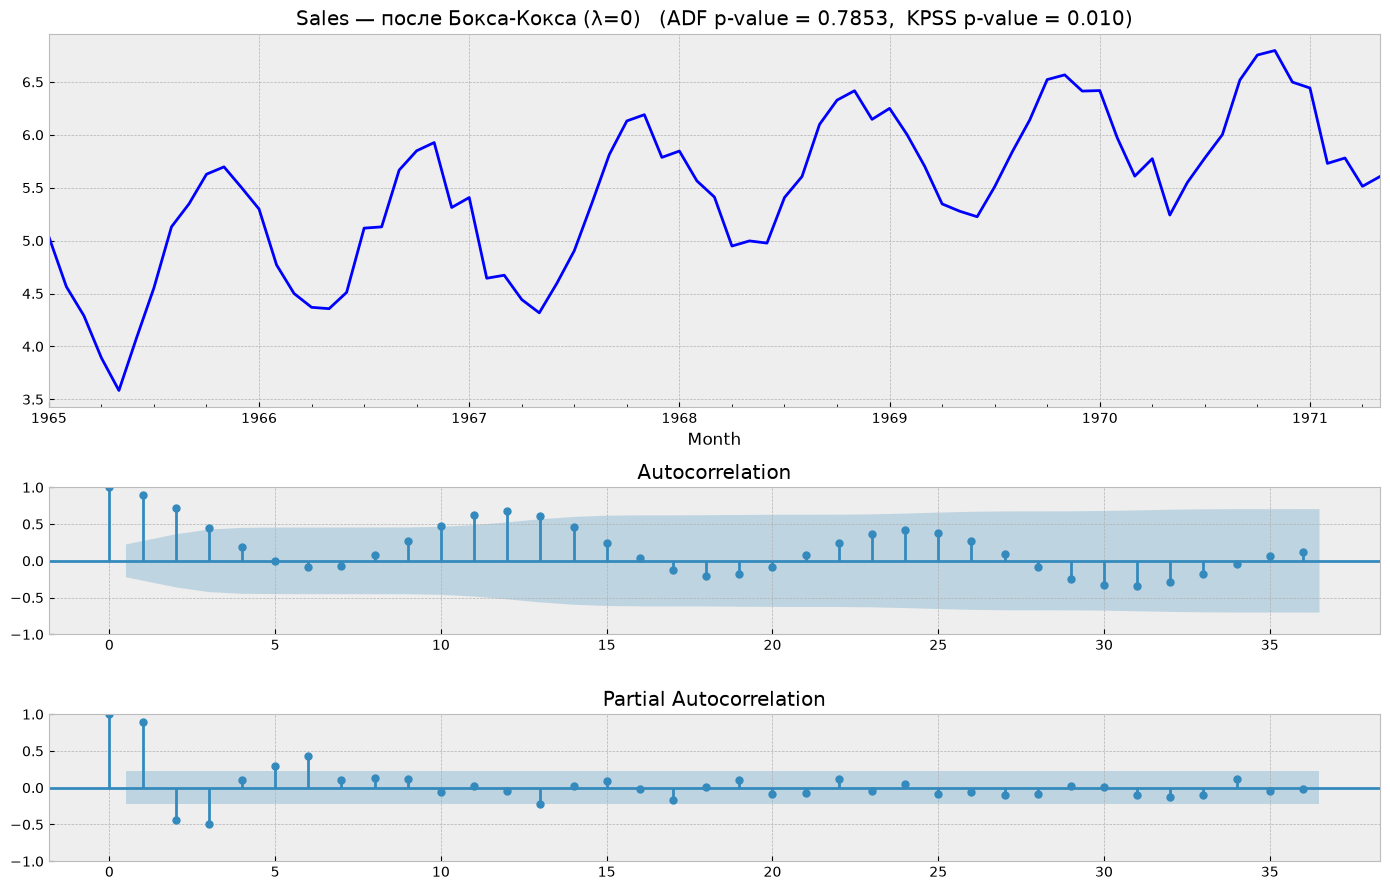

In [11]:
lam_opt = boxcox_normmax(sales.values)
print('Оптимальное λ по Боксу-Коксу: %.3f' % lam_opt)
print('λ заметно меньше 1 => преобразование действительно нужно; берём λ = 0 (логарифм) '
      'как наиболее интерпретируемое.')

sales_log = pd.Series(boxcox(sales.values, 0), index=sales.index)
_ = tsplot(sales_log, lags=36, title='Sales — после Бокса-Кокса (λ=0)')

Размах колебаний выровнялся, но ADF по-прежнему не отвергает `H0` (`p ≈ 0.79`): тренд никуда не делся.

**Шаг 2 — убираем тренд** дифференцированием первого порядка.

Results of Dickey-Fuller Test:
Test Statistic                 -3.135644
p-value                         0.024025
#Lags Used                     11.000000
Number of Observations Used    64.000000
Critical Value (1%)            -3.536928
Critical Value (5%)            -2.907887
Critical Value (10%)           -2.591493

Results of KPSS Test:  statistic = 0.0271, p-value = 0.100 (обрезается в [0.01, 0.10])
Вывод: ADF -> стационарен;  KPSS -> стационарен


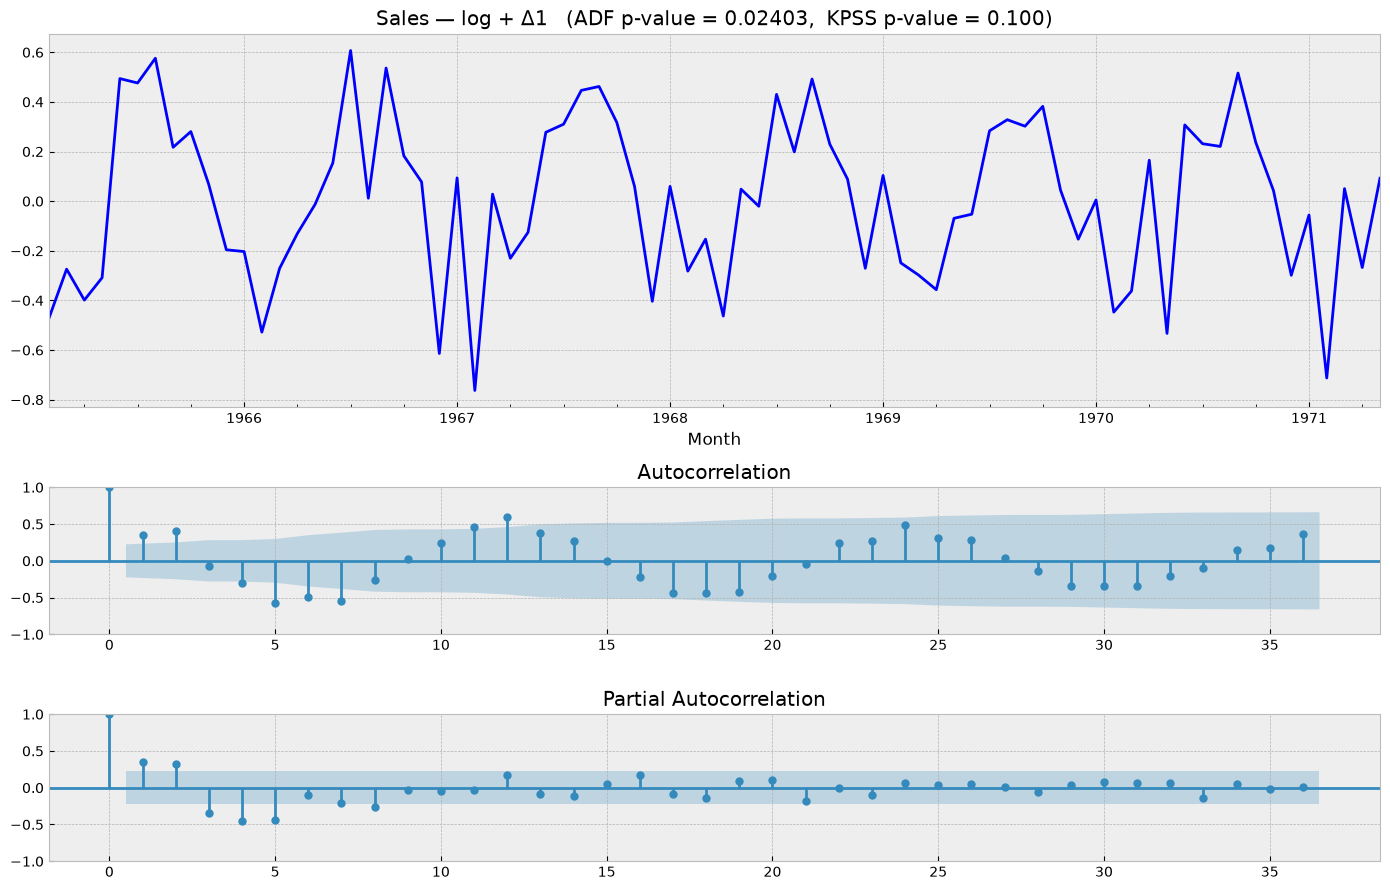

In [12]:
sales_d1 = sales_log.diff(1).dropna()
_ = tsplot(sales_d1, lags=36, title='Sales — log + Δ1')

Тренд ушёл, ADF уже даёт `p ≈ 0.024`. Но на коррелограмме отчётливо торчат лаги **12 и 24**
(ACF ≈ 0.59 и 0.49 при границе значимости ≈ 0.23) — осталась сезонность с периодом 12.
Проверим её явно по среднему профилю месяцев.

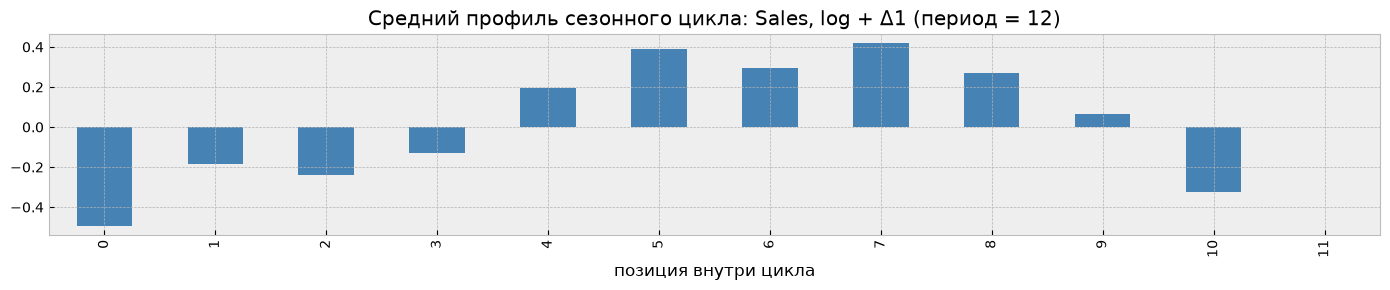

In [13]:
_ = seasonal_profile(sales_d1, period=12, title='Sales, log + Δ1')

Профиль далёк от плоского ⇒ сезонность подтверждена.

**Шаг 3 — убираем сезонность** сезонным дифференцированием с лагом 12.

Results of Dickey-Fuller Test:
Test Statistic                 -2.316045
p-value                         0.166845
#Lags Used                     10.000000
Number of Observations Used    53.000000
Critical Value (1%)            -3.560242
Critical Value (5%)            -2.917850
Critical Value (10%)           -2.596796

Results of KPSS Test:  statistic = 0.0359, p-value = 0.100 (обрезается в [0.01, 0.10])
Вывод: ADF -> НЕ стационарен;  KPSS -> стационарен


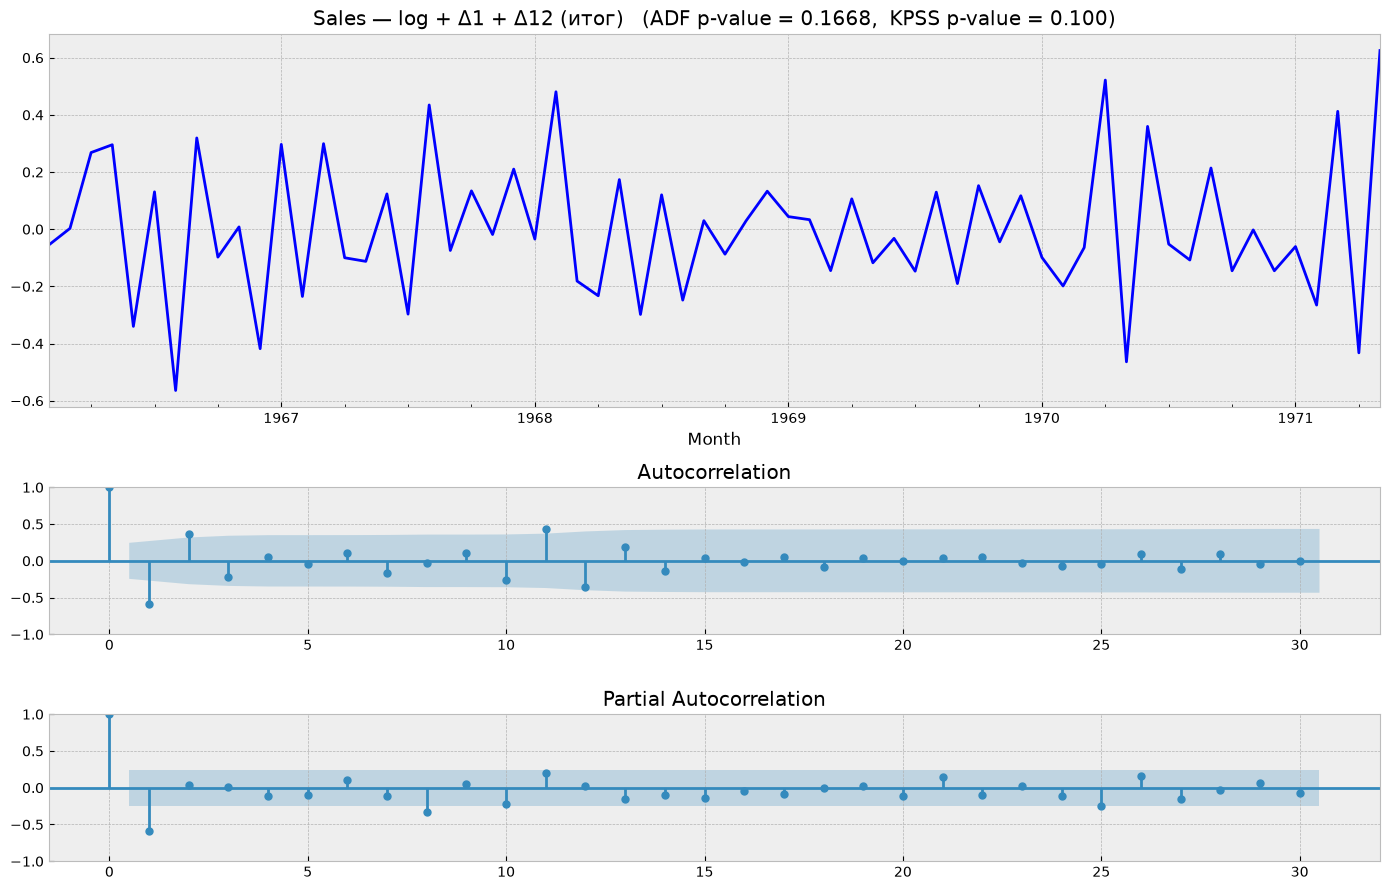

Тест Льюнга-Бокса (H0: автокорреляций нет):
      lb_stat     lb_pvalue
10  44.310404  2.894838e-06
20  75.791764  2.009364e-08


In [14]:
sales_stat = sales_d1.diff(12).dropna()
sales_res = tsplot(sales_stat, lags=30, title='Sales — log + Δ1 + Δ12 (итог)')
ljung_box(sales_stat);

In [15]:
# ADF с автоподбором лагов по AIC на коротком ряде берёт максимум лагов (10 из 64 наблюдений)
# и теряет мощность. Посмотрим, как p-value зависит от числа лагов.
pd.DataFrame(
    [{'maxlag': m, 'ADF p-value': round(adfuller(sales_stat, maxlag=m, autolag=None)[1], 5)}
     for m in [1, 2, 3, 4, 6, 8, 10, 12]]
).set_index('maxlag').T

maxlag,1,2,3,4,6,8,10,12
ADF p-value,0.0,0.00003,0.00002,0.00048,0.04164,0.01062,0.16685,0.20393


**Итог по ряду 1.** После `log + Δ1 + Δ12` на коррелограмме не осталось ни медленного затухания
(тренд), ни всплесков на кратных 12 лагах (сезонность); значимым остался только лаг 1 — это
обычная MA(1)-компонента, которую вносит само дифференцирование, она стационарности не мешает.

Формальные тесты: **KPSS даёт `p > 0.1`** (гипотезу о стационарности не отвергаем).
ADF с автоподбором лагов по AIC показывает `p ≈ 0.17`, однако это артефакт короткого ряда:
после двух дифференцирований осталось всего 64 наблюдения, а AIC выбирает 10 лагов — почти
максимум, из-за чего тест теряет мощность. При разумном числе лагов (1–4) ADF уверенно отвергает
нестационарность (`p` от 1e-8 до 5e-4). Совокупность признаков — ровный уровень, стабильная
дисперсия, чистая коррелограмма, KPSS и ADF с умеренным числом лагов — говорит, что ряд стационарен.

In [16]:
remember('Monthly sales of company X', sales_raw_res, sales_stat, 'Box-Cox(λ=0) + Δ1 + Δ12');

---
# Ряд 2. Monthly Boston armed robberies

Число вооружённых ограблений в Бостоне, январь 1966 — октябрь 1975, 118 наблюдений.

### 2.1. Исходный ряд

Results of Dickey-Fuller Test:
Test Statistic                   1.001102
p-value                          0.994278
#Lags Used                      11.000000
Number of Observations Used    106.000000
Critical Value (1%)             -3.493602
Critical Value (5%)             -2.889217
Critical Value (10%)            -2.581533

Results of KPSS Test:  statistic = 1.7119, p-value = 0.010 (обрезается в [0.01, 0.10])
Вывод: ADF -> НЕ стационарен;  KPSS -> НЕ стационарен


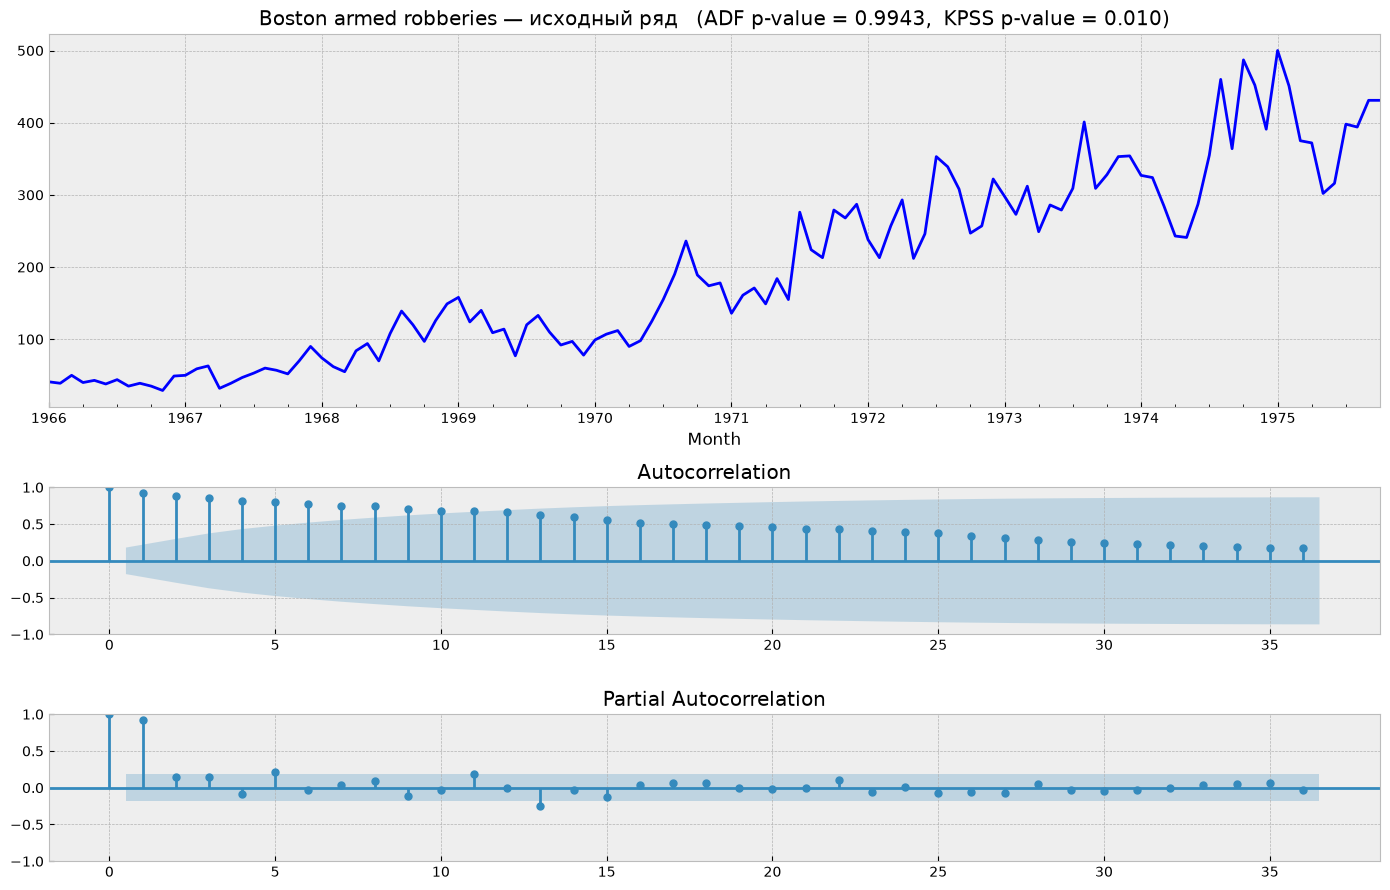

In [17]:
robb_raw_res = tsplot(robberies, lags=36, title='Boston armed robberies — исходный ряд')

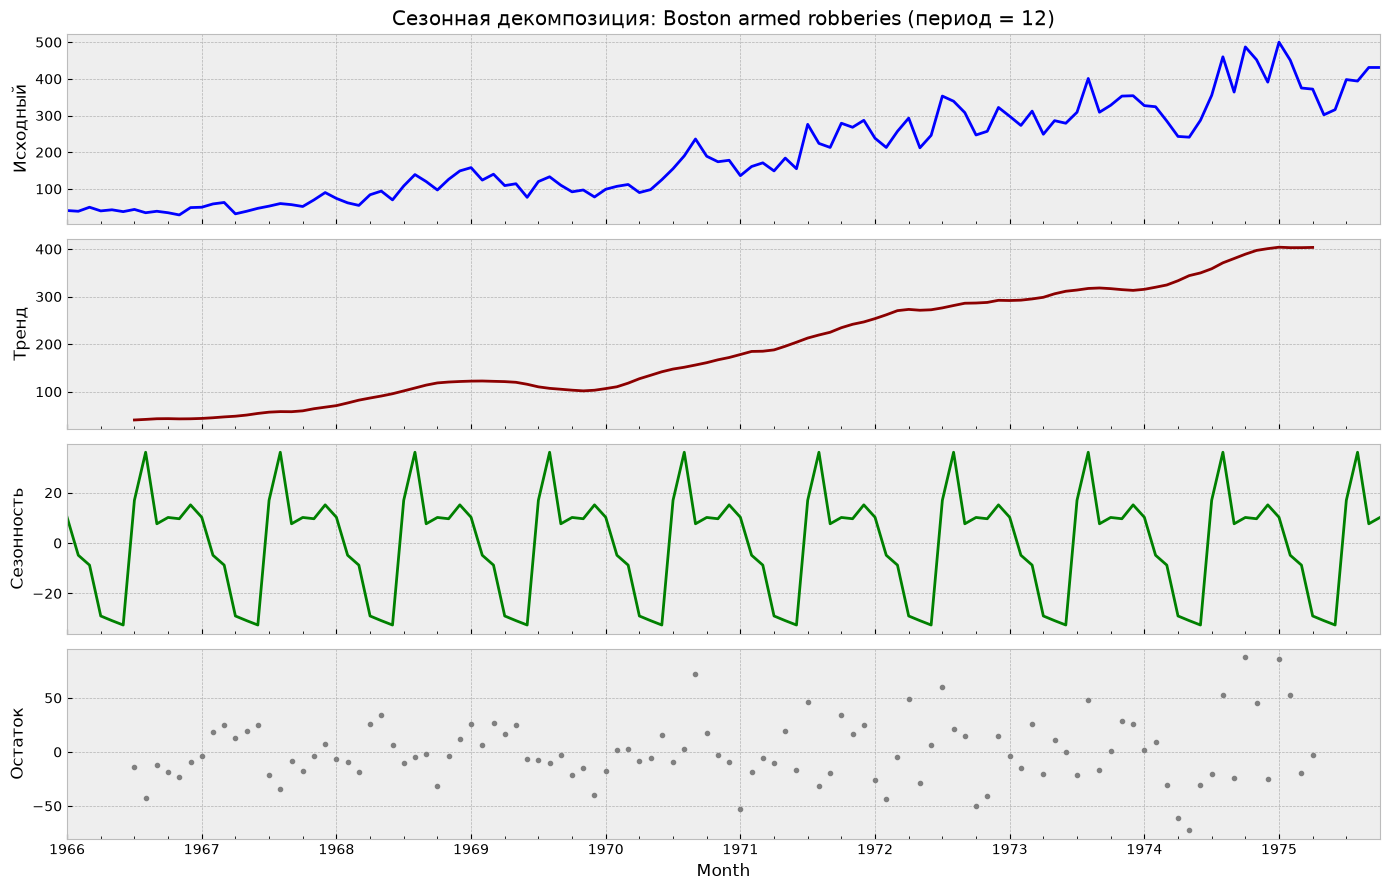

In [18]:
plot_decomposition(robberies, period=12, title='Boston armed robberies');

**Что видим.** Ряд вырос с ~40 до ~430 случаев в месяц — мощный тренд. ADF `p ≈ 0.99`,
ACF затухает почти линейно и остаётся значимой на всех 36 лагах — классическая картина
нестационарного ряда с трендом. Разброс вокруг тренда растёт пропорционально уровню,
значит сначала логарифмируем.

Оптимальное λ по Боксу-Коксу: 0.410
Results of Dickey-Fuller Test:
Test Statistic                  -2.013161
p-value                          0.280833
#Lags Used                      10.000000
Number of Observations Used    107.000000
Critical Value (1%)             -3.492996
Critical Value (5%)             -2.888955
Critical Value (10%)            -2.581393

Results of KPSS Test:  statistic = 1.6955, p-value = 0.010 (обрезается в [0.01, 0.10])
Вывод: ADF -> НЕ стационарен;  KPSS -> НЕ стационарен


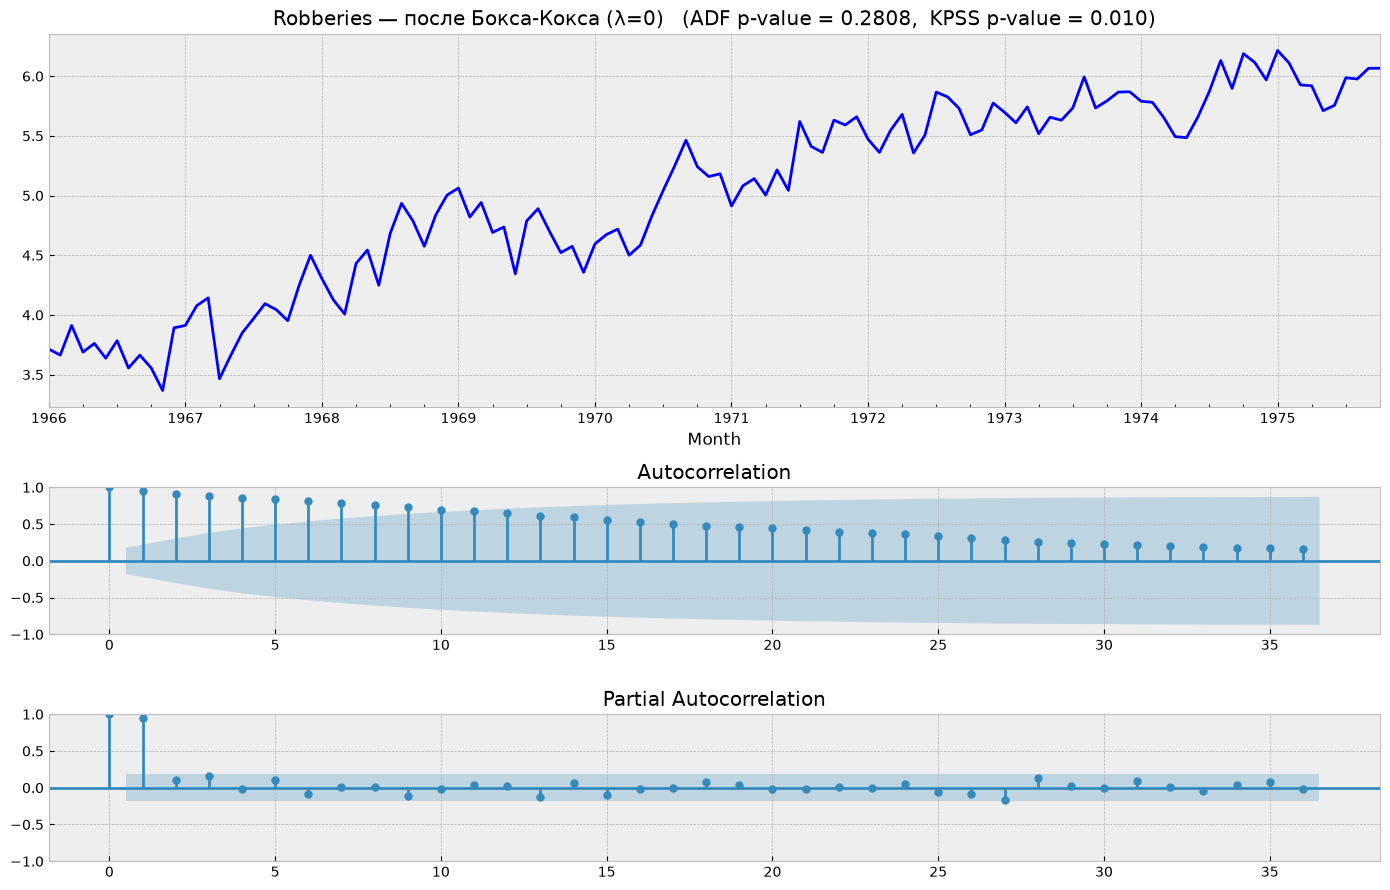

In [19]:
print('Оптимальное λ по Боксу-Коксу: %.3f' % boxcox_normmax(robberies.values))

robberies_log = pd.Series(boxcox(robberies.values, 0), index=robberies.index)
_ = tsplot(robberies_log, lags=36, title='Robberies — после Бокса-Кокса (λ=0)')

После логарифмирования рост стал близок к линейному, а размах колебаний — однородным.
Тренд остался (`ADF p ≈ 0.28`), убираем его дифференцированием.

Results of Dickey-Fuller Test:
Test Statistic                -7.601792e+00
p-value                        2.378602e-11
#Lags Used                     3.000000e+00
Number of Observations Used    1.130000e+02
Critical Value (1%)           -3.489590e+00
Critical Value (5%)           -2.887477e+00
Critical Value (10%)          -2.580604e+00

Results of KPSS Test:  statistic = 0.0897, p-value = 0.100 (обрезается в [0.01, 0.10])
Вывод: ADF -> стационарен;  KPSS -> стационарен


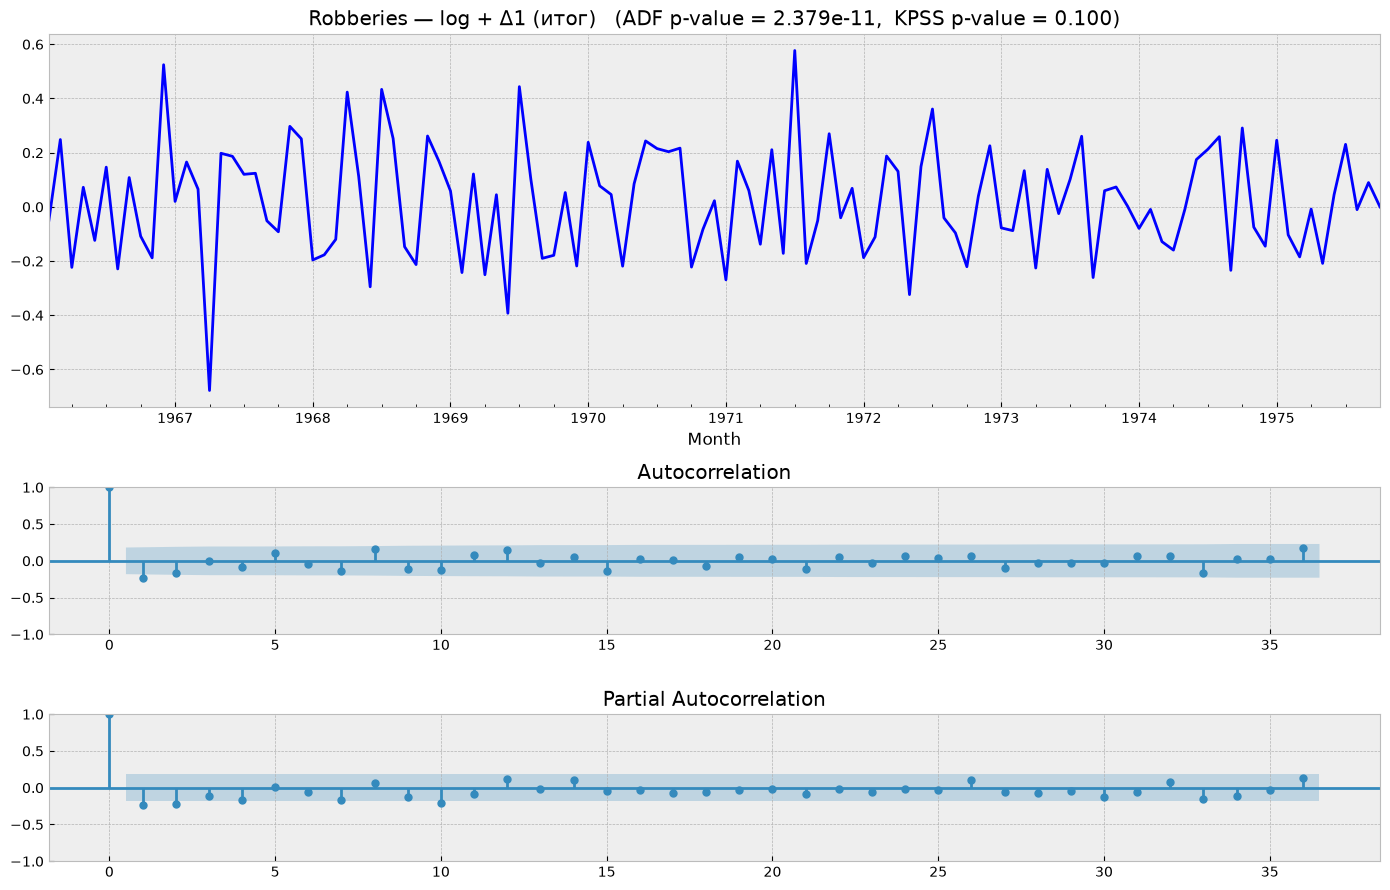

Тест Льюнга-Бокса (H0: автокорреляций нет):
      lb_stat  lb_pvalue
10  20.827073   0.022332
20  28.621828   0.095477


In [20]:
robberies_stat = robberies_log.diff(1).dropna()
robb_res = tsplot(robberies_stat, lags=36, title='Robberies — log + Δ1 (итог)')
ljung_box(robberies_stat);

**Нужно ли сезонное дифференцирование?** На коррелограмме после `log + Δ1` значим только лаг 1
(ACF ≈ −0.23), на лагах 12 и 24 всплесков нет — выраженной годовой сезонности в ряде не осталось
(она была слабой и «съелась» вместе с трендом). Проверим это и убедимся, что лишнее
дифференцирование только ухудшит ряд.

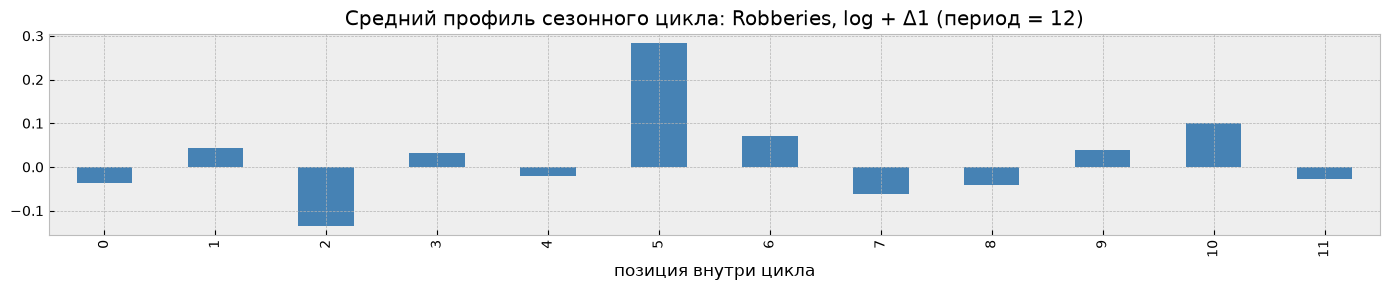

Стандартное отклонение log + Δ1        : 0.2071
Стандартное отклонение log + Δ1 + Δ12  : 0.2725  <- выросло, это передифференцирование


In [21]:
_ = seasonal_profile(robberies_stat, period=12, title='Robberies, log + Δ1')

over_differenced = robberies_stat.diff(12).dropna()
print('Стандартное отклонение log + Δ1        : %.4f' % robberies_stat.std())
print('Стандартное отклонение log + Δ1 + Δ12  : %.4f  <- выросло, это передифференцирование'
      % over_differenced.std())

Дисперсия после лишнего сезонного дифференцирования выросла, а в ACF появился искусственный
отрицательный выброс на лаге 12 — классический признак передифференцирования. Останавливаемся
на `log + Δ1`.

**Итог по ряду 2.** `ADF p ≈ 2.4e-11` (нестационарность уверенно отвергнута), `KPSS p > 0.1`
(стационарность не отвергнута). Ряд стационарен.

In [22]:
remember('Monthly Boston armed robberies', robb_raw_res, robberies_stat, 'Box-Cox(λ=0) + Δ1');

---
# Ряд 3. International airline passengers

Международные авиаперевозки, тыс. пассажиров в месяц, январь 1949 — декабрь 1960, 144 наблюдения.
Хрестоматийный пример ряда с мультипликативной сезонностью.

### 3.1. Исходный ряд

Results of Dickey-Fuller Test:
Test Statistic                   0.815369
p-value                          0.991880
#Lags Used                      13.000000
Number of Observations Used    130.000000
Critical Value (1%)             -3.481682
Critical Value (5%)             -2.884042
Critical Value (10%)            -2.578770

Results of KPSS Test:  statistic = 1.6513, p-value = 0.010 (обрезается в [0.01, 0.10])
Вывод: ADF -> НЕ стационарен;  KPSS -> НЕ стационарен


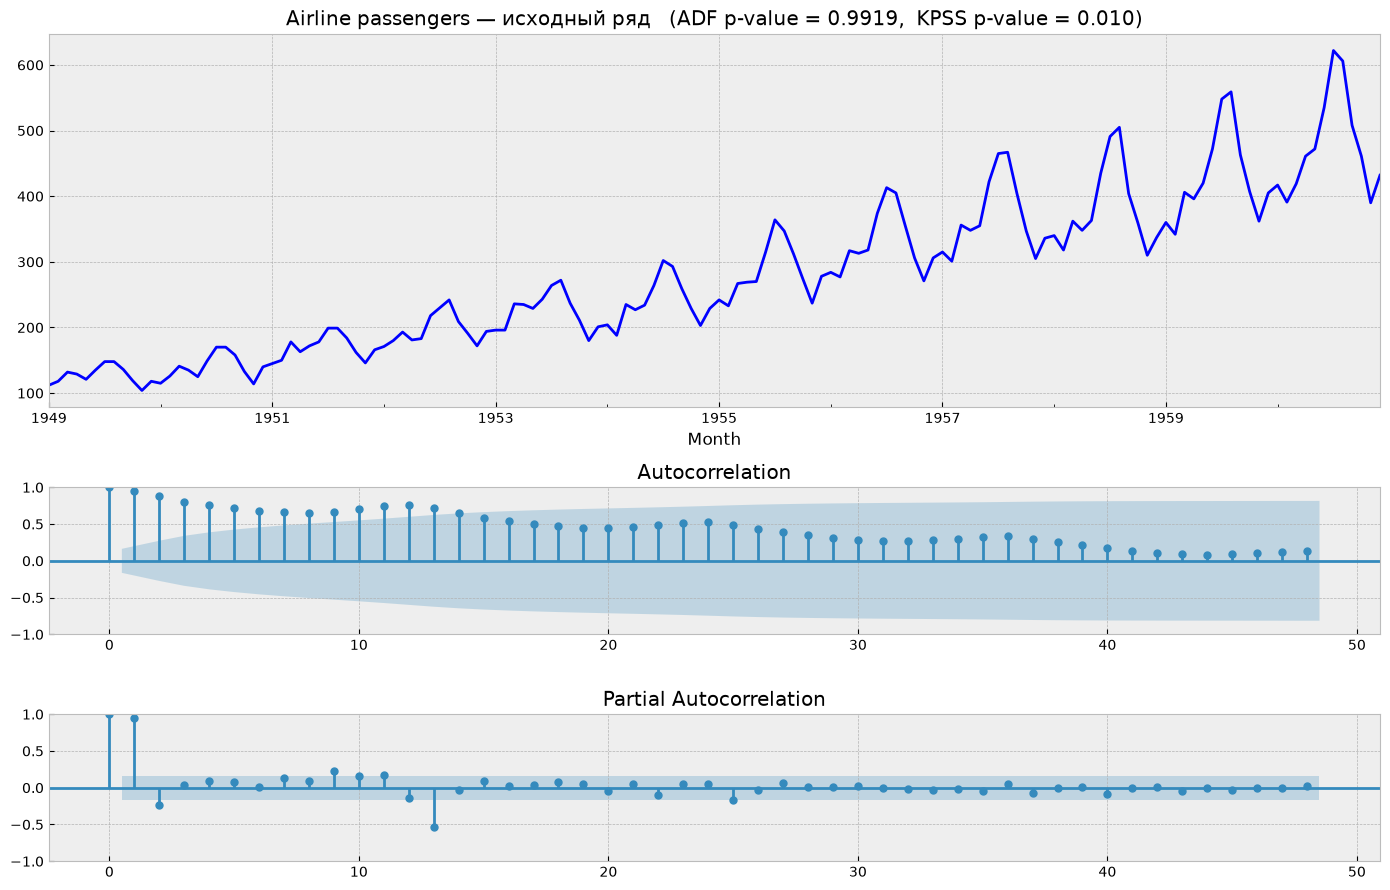

In [23]:
air_raw_res = tsplot(airline, lags=48, title='Airline passengers — исходный ряд')

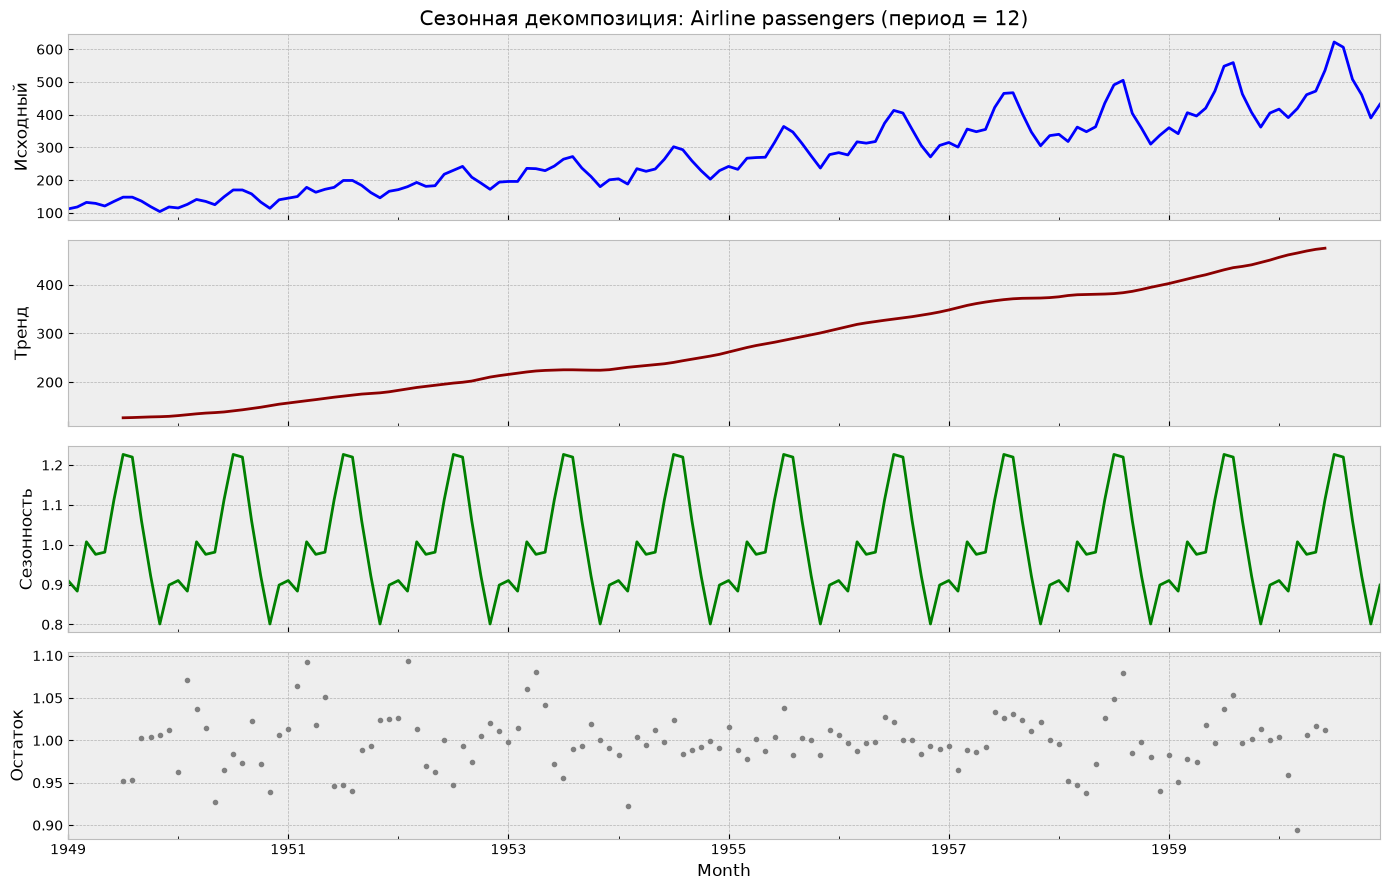

In [24]:
plot_decomposition(airline, period=12, title='Airline passengers', model='multiplicative');

**Что видим.** Растущий тренд, годовая сезонность с летним пиком и — главное — амплитуда
сезонных колебаний растёт вместе с уровнем ряда, то есть сезонность **мультипликативная**.
Именно такую зависимость логарифм превращает в аддитивную.

Оптимальное λ по Боксу-Коксу: 0.211  (близко к 0 => логарифм)
Results of Dickey-Fuller Test:
Test Statistic                  -1.717017
p-value                          0.422367
#Lags Used                      13.000000
Number of Observations Used    130.000000
Critical Value (1%)             -3.481682
Critical Value (5%)             -2.884042
Critical Value (10%)            -2.578770

Results of KPSS Test:  statistic = 1.6687, p-value = 0.010 (обрезается в [0.01, 0.10])
Вывод: ADF -> НЕ стационарен;  KPSS -> НЕ стационарен


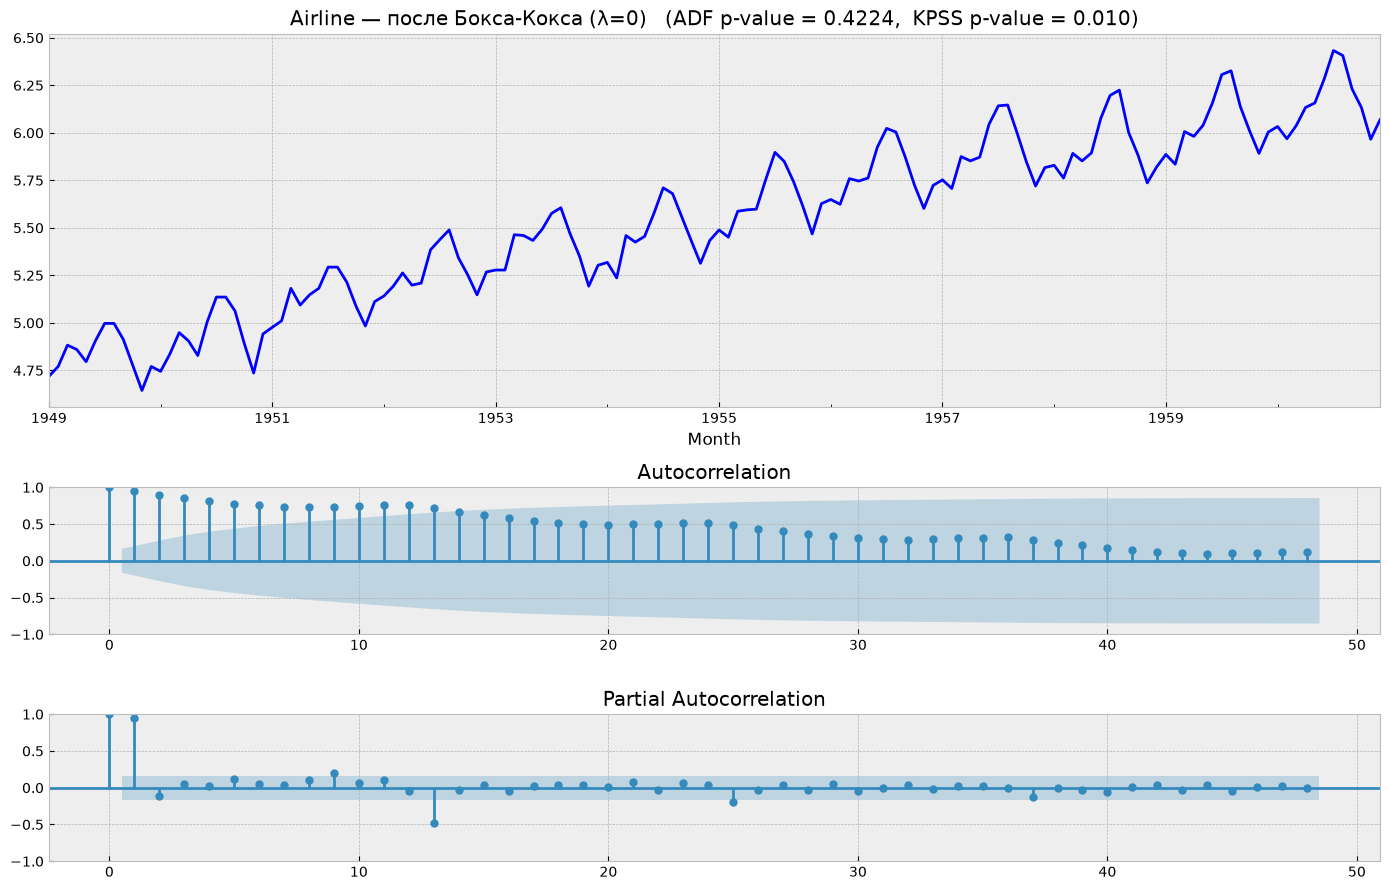

In [25]:
print('Оптимальное λ по Боксу-Коксу: %.3f  (близко к 0 => логарифм)'
      % boxcox_normmax(airline.values))

airline_log = pd.Series(boxcox(airline.values, 0), index=airline.index)
_ = tsplot(airline_log, lags=48, title='Airline — после Бокса-Кокса (λ=0)')

Размах сезонных волн выровнялся по всей длине ряда. Теперь убираем тренд.

Results of Dickey-Fuller Test:
Test Statistic                  -2.717131
p-value                          0.071121
#Lags Used                      14.000000
Number of Observations Used    128.000000
Critical Value (1%)             -3.482501
Critical Value (5%)             -2.884398
Critical Value (10%)            -2.578960

Results of KPSS Test:  statistic = 0.0383, p-value = 0.100 (обрезается в [0.01, 0.10])
Вывод: ADF -> НЕ стационарен;  KPSS -> стационарен


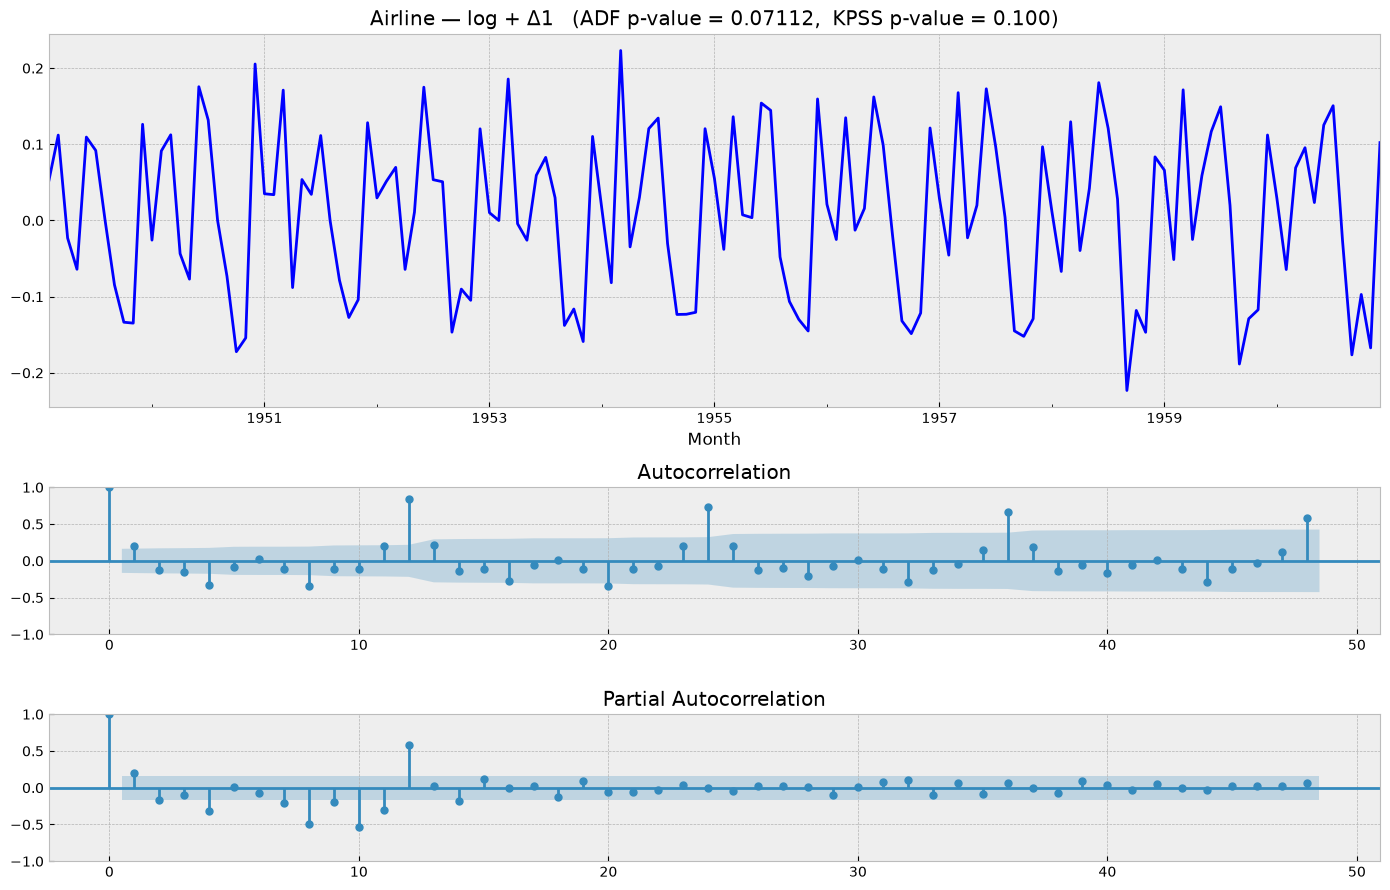

In [26]:
airline_d1 = airline_log.diff(1).dropna()
_ = tsplot(airline_d1, lags=48, title='Airline — log + Δ1')

Тренд ушёл, но сезонность видна невооружённым глазом: ACF на лаге 12 равна **0.84**, на лаге 24 — **0.74**.
Убираем сезонным дифференцированием с лагом 12.

Results of Dickey-Fuller Test:
Test Statistic                  -4.443325
p-value                          0.000249
#Lags Used                      12.000000
Number of Observations Used    118.000000
Critical Value (1%)             -3.487022
Critical Value (5%)             -2.886363
Critical Value (10%)            -2.580009

Results of KPSS Test:  statistic = 0.0732, p-value = 0.100 (обрезается в [0.01, 0.10])
Вывод: ADF -> стационарен;  KPSS -> стационарен


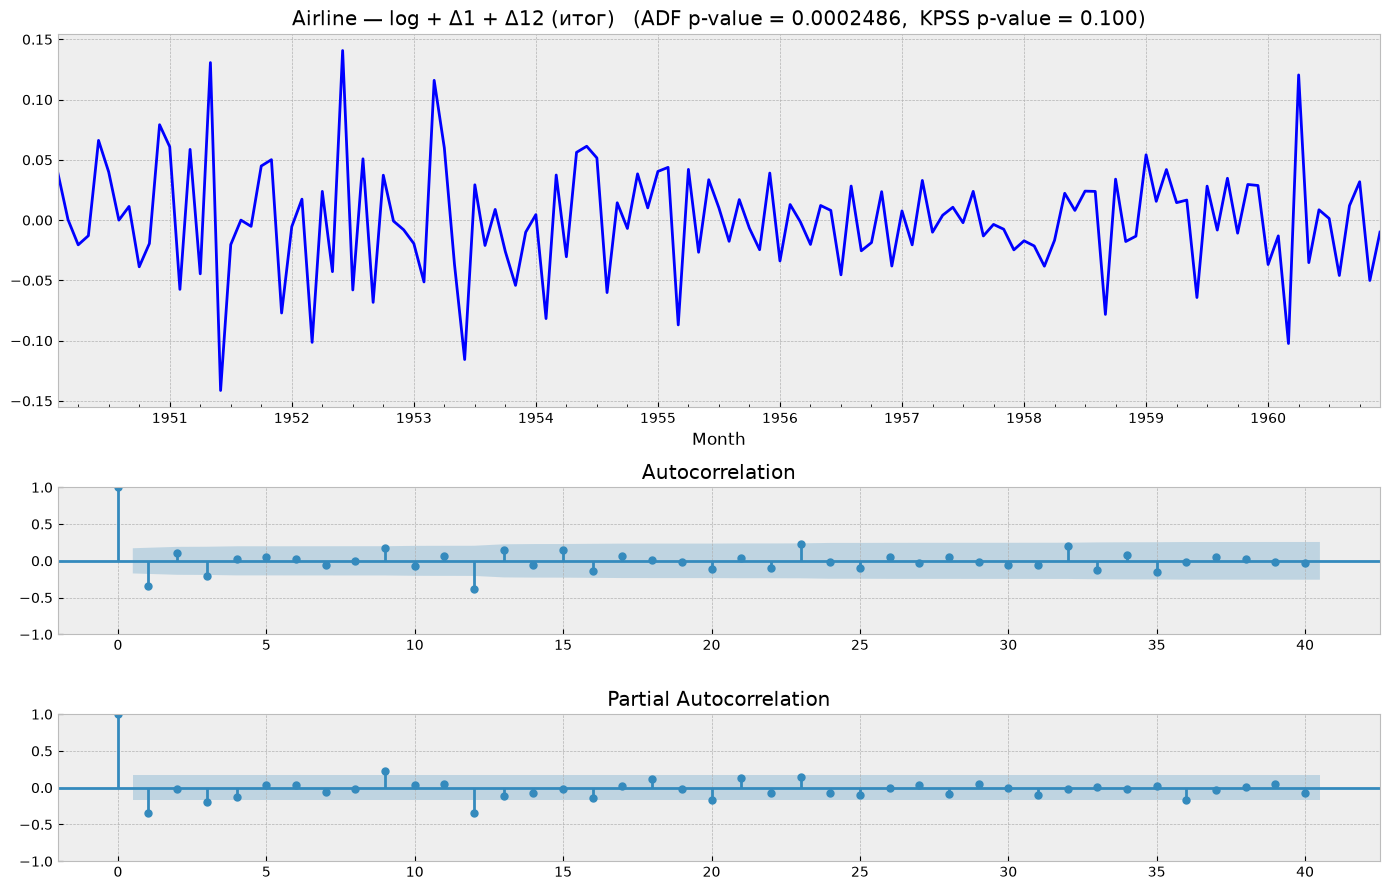

Тест Льюнга-Бокса (H0: автокорреляций нет):
      lb_stat  lb_pvalue
10  28.986885   0.001252
20  64.598369   0.000001


In [27]:
airline_stat = airline_d1.diff(12).dropna()
air_res = tsplot(airline_stat, lags=40, title='Airline — log + Δ1 + Δ12 (итог)')
ljung_box(airline_stat);

**Итог по ряду 3.** `ADF p ≈ 2.5e-4`, `KPSS p > 0.1` — оба теста согласованно говорят о
стационарности. На коррелограмме остались только значимые лаги 1 и 12 с отрицательным знаком —
это сигнатура сезонной модели `ARIMA(0,1,1)(0,1,1)₁₂`, то есть MA-компоненты, внесённые самими
дифференцированиями. Ряд стационарен.

In [28]:
remember('International airline passengers', air_raw_res, airline_stat, 'Box-Cox(λ=0) + Δ1 + Δ12');

---
# Ряд 4. Mean monthly air temperature (Nottingham Castle)

Средняя месячная температура воздуха в °F, январь 1920 — декабрь 1939, 240 наблюдений.

### 4.1. Исходный ряд

Results of Dickey-Fuller Test:
Test Statistic                  -3.255492
p-value                          0.016989
#Lags Used                      14.000000
Number of Observations Used    225.000000
Critical Value (1%)             -3.459752
Critical Value (5%)             -2.874473
Critical Value (10%)            -2.573663

Results of KPSS Test:  statistic = 0.0439, p-value = 0.100 (обрезается в [0.01, 0.10])
Вывод: ADF -> стационарен;  KPSS -> стационарен


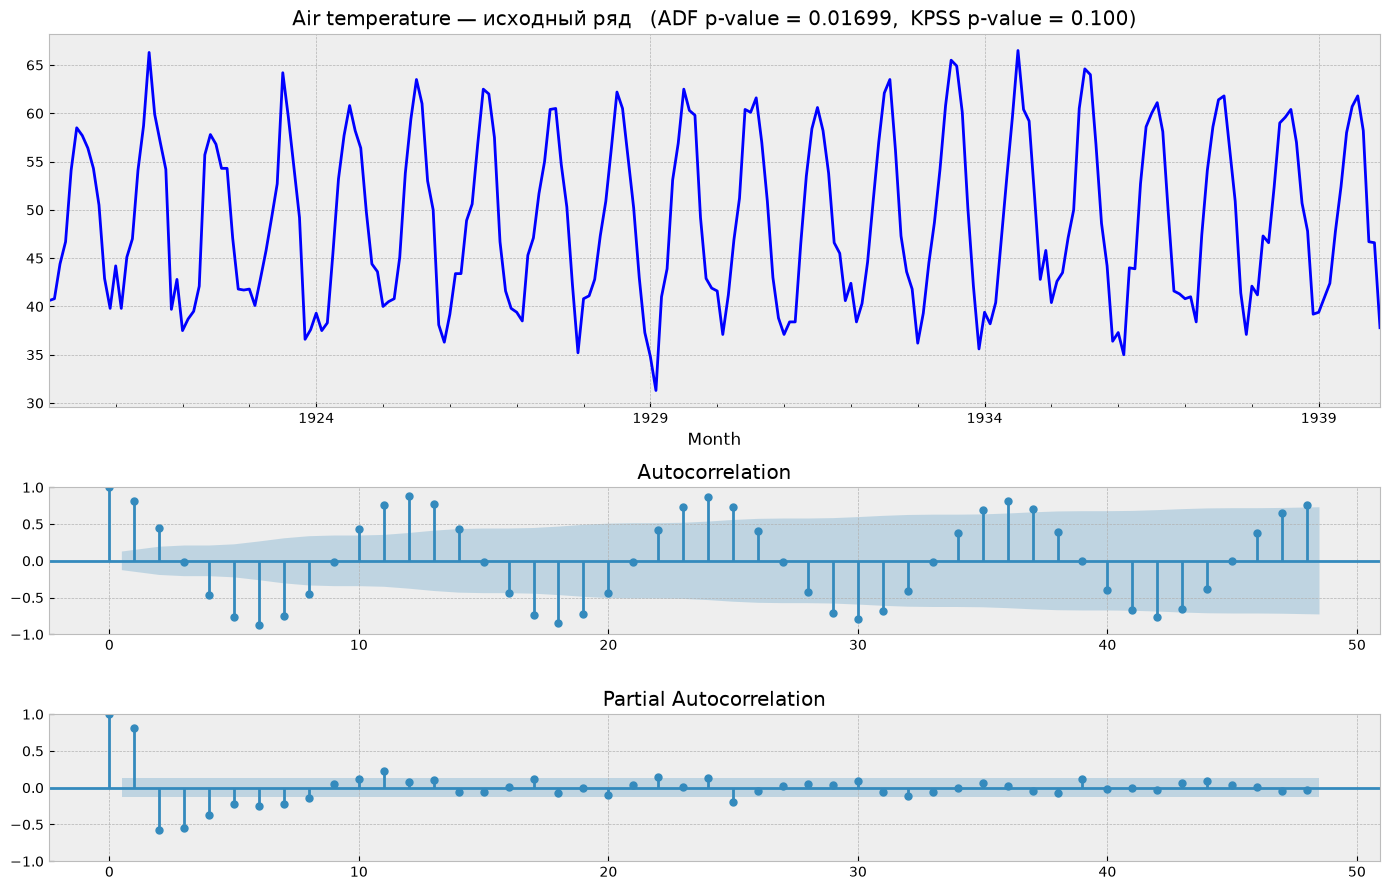

In [29]:
temp_raw_res = tsplot(temperature, lags=48, title='Air temperature — исходный ряд')

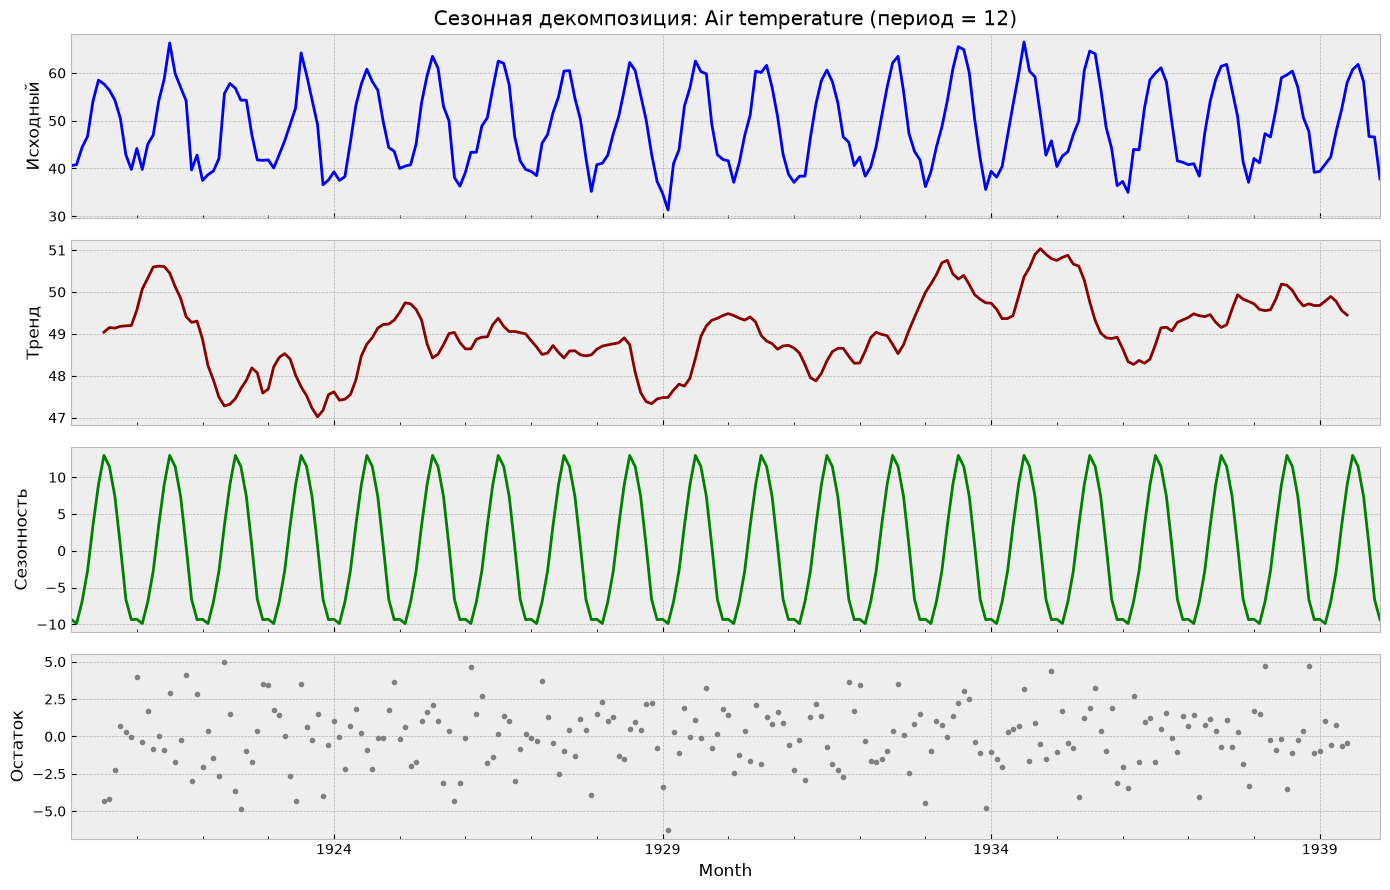

In [30]:
plot_decomposition(temperature, period=12, title='Air temperature');

**Что видим.** Тренда нет — уровень ряда за 20 лет не сместился. Зато сезонность идеально
регулярная: ACF — это чистая синусоида с максимумами на лагах 12, 24, 36 (0.88, 0.87, ...)
и минимумами на 6, 18, 30. Амплитуда сезонных колебаний постоянна, значит **преобразование
Бокса–Кокса не нужно** (и дифференцирование первого порядка тоже — тренда нет).

Обратите внимание на расхождение тестов на исходном ряде: ADF даёт `p ≈ 0.017` и формально
«отвергает нестационарность», а KPSS — `p ≈ 0.1`. Это тот случай, когда формальным тестам
верить нельзя: ADF проверяет только наличие **единичного корня**, а детерминированная сезонность
единичного корня не создаёт. Ряд при этом очевидно нестационарен — его математическое ожидание
меняется от месяца к месяцу (летом теплее, чем зимой). Решает дело коррелограмма.

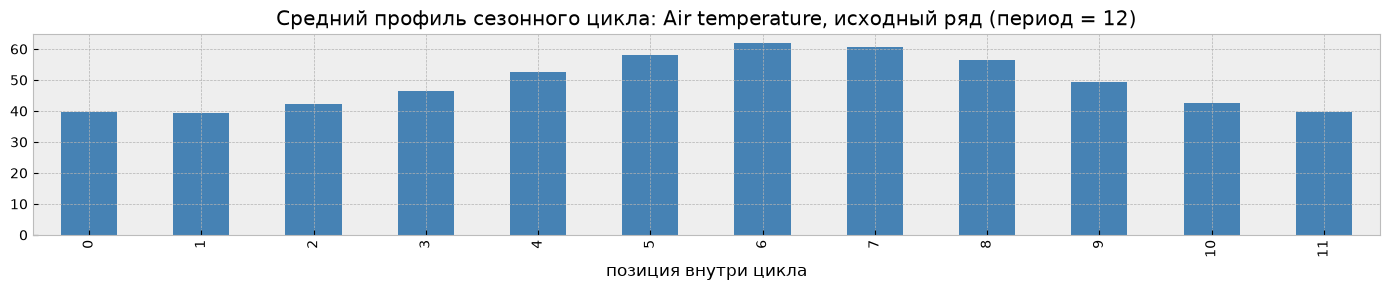

In [31]:
_ = seasonal_profile(temperature, period=12, title='Air temperature, исходный ряд')

Профиль — явная годовая волна от ~40 °F в январе до ~62 °F в июле. Убираем сезонность
дифференцированием с лагом 12.

Results of Dickey-Fuller Test:
Test Statistic                -6.072501e+00
p-value                        1.141945e-07
#Lags Used                     1.200000e+01
Number of Observations Used    2.150000e+02
Critical Value (1%)           -3.461136e+00
Critical Value (5%)           -2.875079e+00
Critical Value (10%)          -2.573986e+00

Results of KPSS Test:  statistic = 0.0268, p-value = 0.100 (обрезается в [0.01, 0.10])
Вывод: ADF -> стационарен;  KPSS -> стационарен


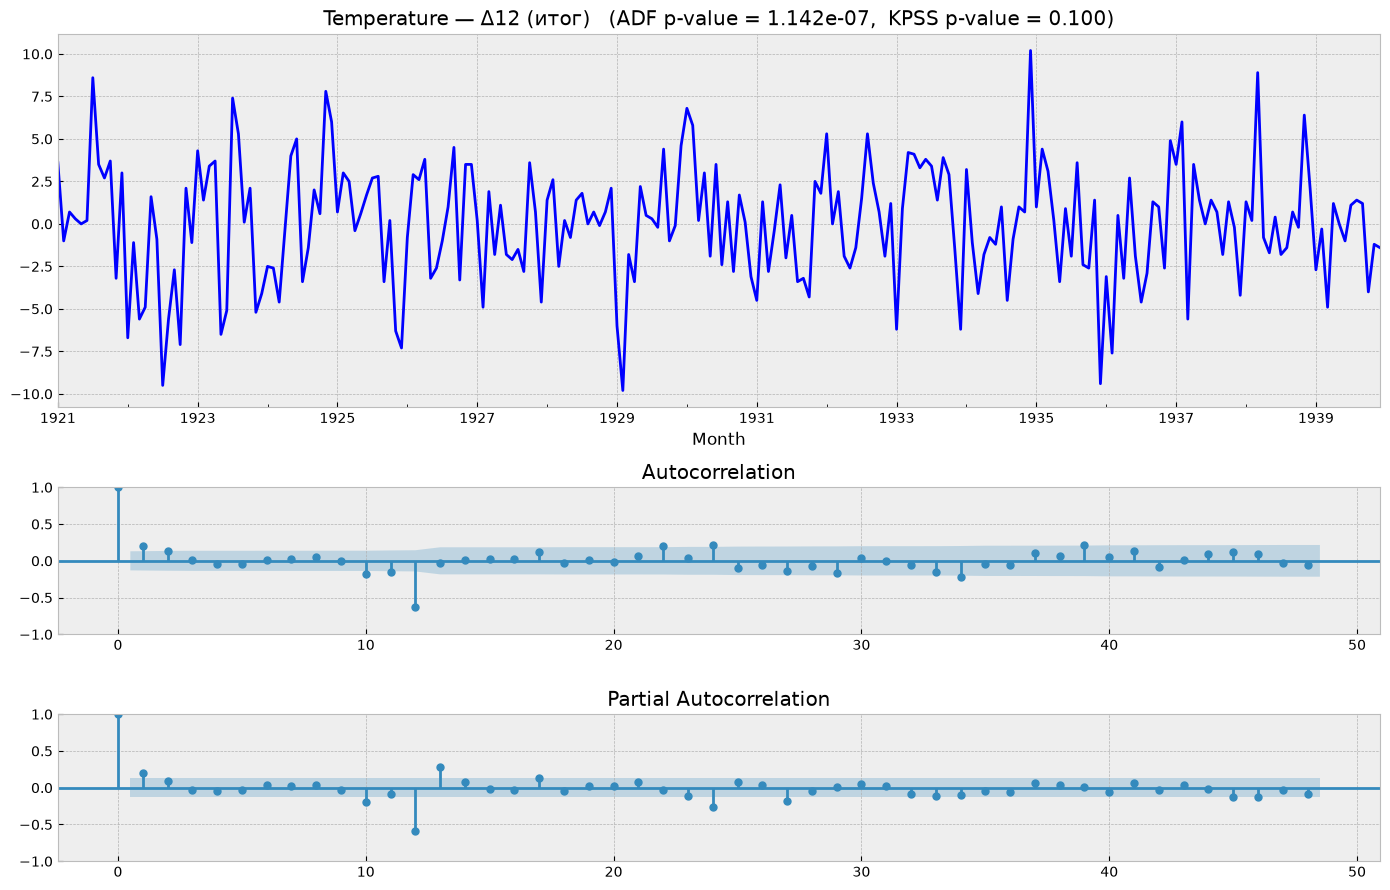

Тест Льюнга-Бокса (H0: автокорреляций нет):
       lb_stat     lb_pvalue
10   22.078236  1.471096e-02
20  126.456820  1.795186e-17


In [32]:
temperature_stat = temperature.diff(12).dropna()
temp_res = tsplot(temperature_stat, lags=48, title='Temperature — Δ12 (итог)')
ljung_box(temperature_stat);

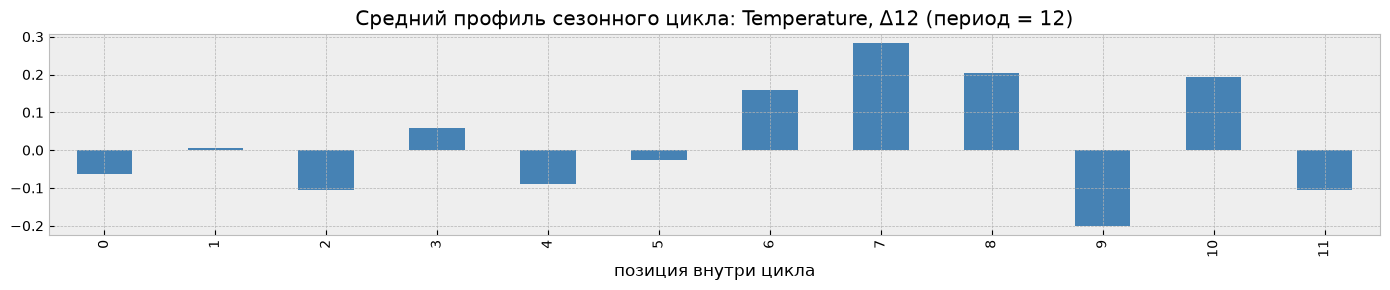

In [33]:
_ = seasonal_profile(temperature_stat, period=12, title='Temperature, Δ12')

**Итог по ряду 4.** `ADF p ≈ 1.1e-7`, `KPSS p > 0.1`. Сезонная волна в ACF исчезла, профиль
месяцев стал плоским. Остался значимый отрицательный лаг 12 (≈ −0.63) — MA-компонента от
сезонного дифференцирования. Применять ещё и `Δ1` здесь не нужно: тренда в ряде нет,
а лишнее дифференцирование только раздует дисперсию. Ряд стационарен.

In [34]:
remember('Mean monthly air temperature', temp_raw_res, temperature_stat, 'Δ12 (без Бокса-Кокса и без Δ1)');

---
# Ряд 5. Weekly closings of the Dow-Jones industrial average

Недельные значения закрытия индекса Dow Jones, июль 1971 — август 1974, 162 наблюдения.

### 5.1. Исходный ряд

Results of Dickey-Fuller Test:
Test Statistic                  -1.314625
p-value                          0.622455
#Lags Used                       0.000000
Number of Observations Used    161.000000
Critical Value (1%)             -3.471633
Critical Value (5%)             -2.879665
Critical Value (10%)            -2.576434

Results of KPSS Test:  statistic = 0.5834, p-value = 0.024 (обрезается в [0.01, 0.10])
Вывод: ADF -> НЕ стационарен;  KPSS -> НЕ стационарен


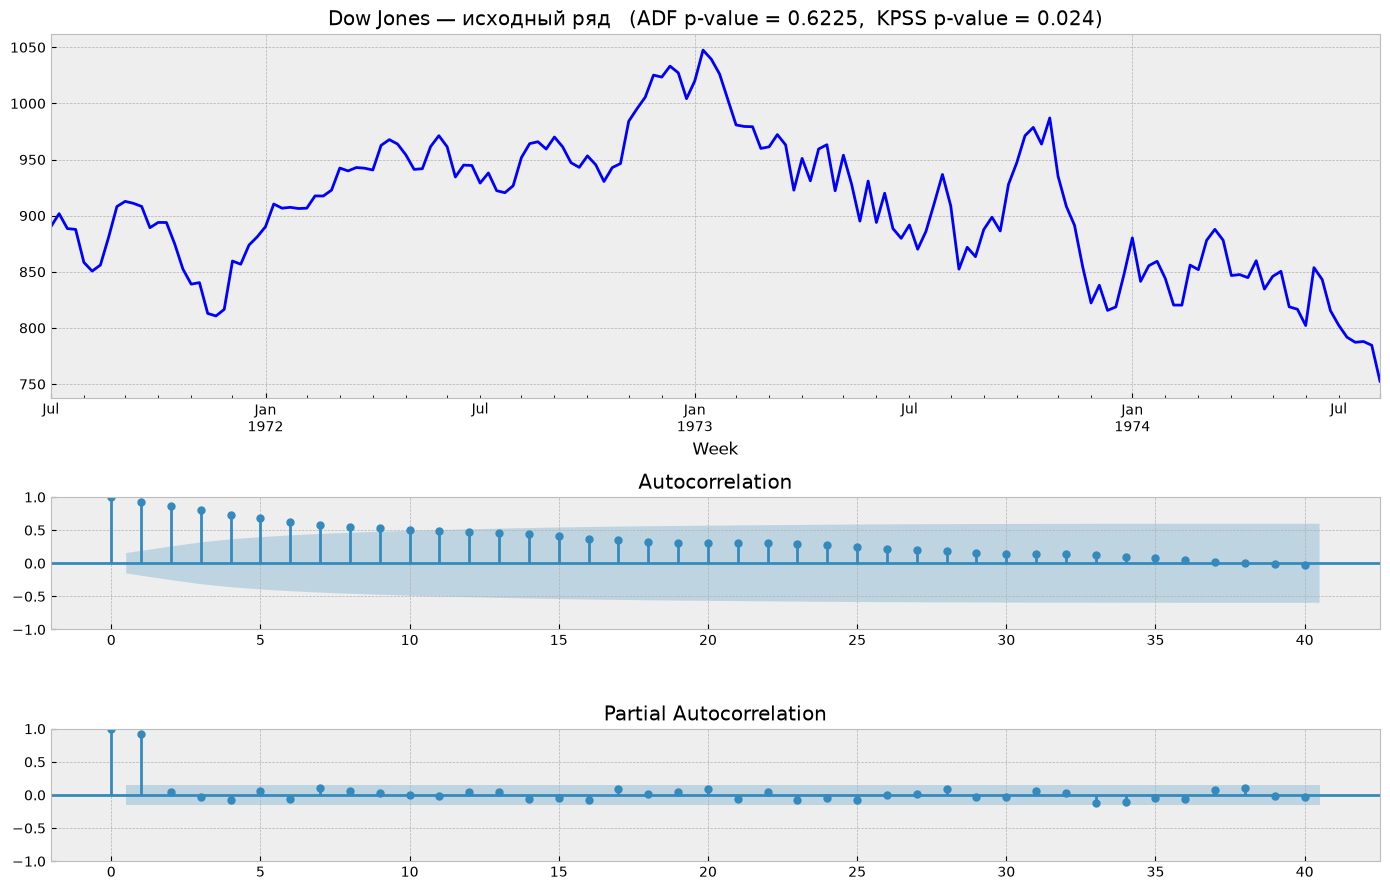

In [35]:
dj_raw_res = tsplot(dowjones, lags=40, title='Dow Jones — исходный ряд')

**Что видим.** Это классическое **случайное блуждание**: тренда в привычном смысле нет, но
уровень ряда «уплывает», ACF затухает очень медленно и остаётся значимой на всех 40 лагах,
а PACF имеет единственный огромный выброс на лаге 1 (≈ 1.0) и обрывается — ровно такая структура
у процесса `y_t = y_{t−1} + ε_t`. ADF даёт `p ≈ 0.62`: единичный корень есть.

Сезонности нет — ни на одном лаге нет периодических всплесков, что логично: у недельных
биржевых котировок нет годового цикла.

Нужно ли преобразование Бокса–Кокса? Ряд колеблется в узком коридоре 750–1050 (отношение
max/min ≈ 1.4), размах колебаний от уровня не зависит.

In [36]:
print('Оптимальное λ по Боксу-Коксу: %.3f  (близко к 1 => преобразование не требуется)'
      % boxcox_normmax(dowjones.values))
print('max / min = %.2f' % (dowjones.max() / dowjones.min()))

# сравним разброс в первой и второй половине ряда
half = len(dowjones) // 2
print('std первой половины : %.2f' % dowjones.iloc[:half].diff().std())
print('std второй половины : %.2f' % dowjones.iloc[half:].diff().std())

Оптимальное λ по Боксу-Коксу: 1.178  (близко к 1 => преобразование не требуется)
max / min = 1.39
std первой половины : 14.34
std второй половины : 24.01


λ ≈ 1.13, то есть оптимальное преобразование Бокса–Кокса — это почти тождественное.
Логарифмирование здесь ничего не даст, ограничиваемся дифференцированием первого порядка.

Results of Dickey-Fuller Test:
Test Statistic                -1.302521e+01
p-value                        2.407586e-24
#Lags Used                     0.000000e+00
Number of Observations Used    1.600000e+02
Critical Value (1%)           -3.471896e+00
Critical Value (5%)           -2.879780e+00
Critical Value (10%)          -2.576495e+00

Results of KPSS Test:  statistic = 0.1848, p-value = 0.100 (обрезается в [0.01, 0.10])
Вывод: ADF -> стационарен;  KPSS -> стационарен


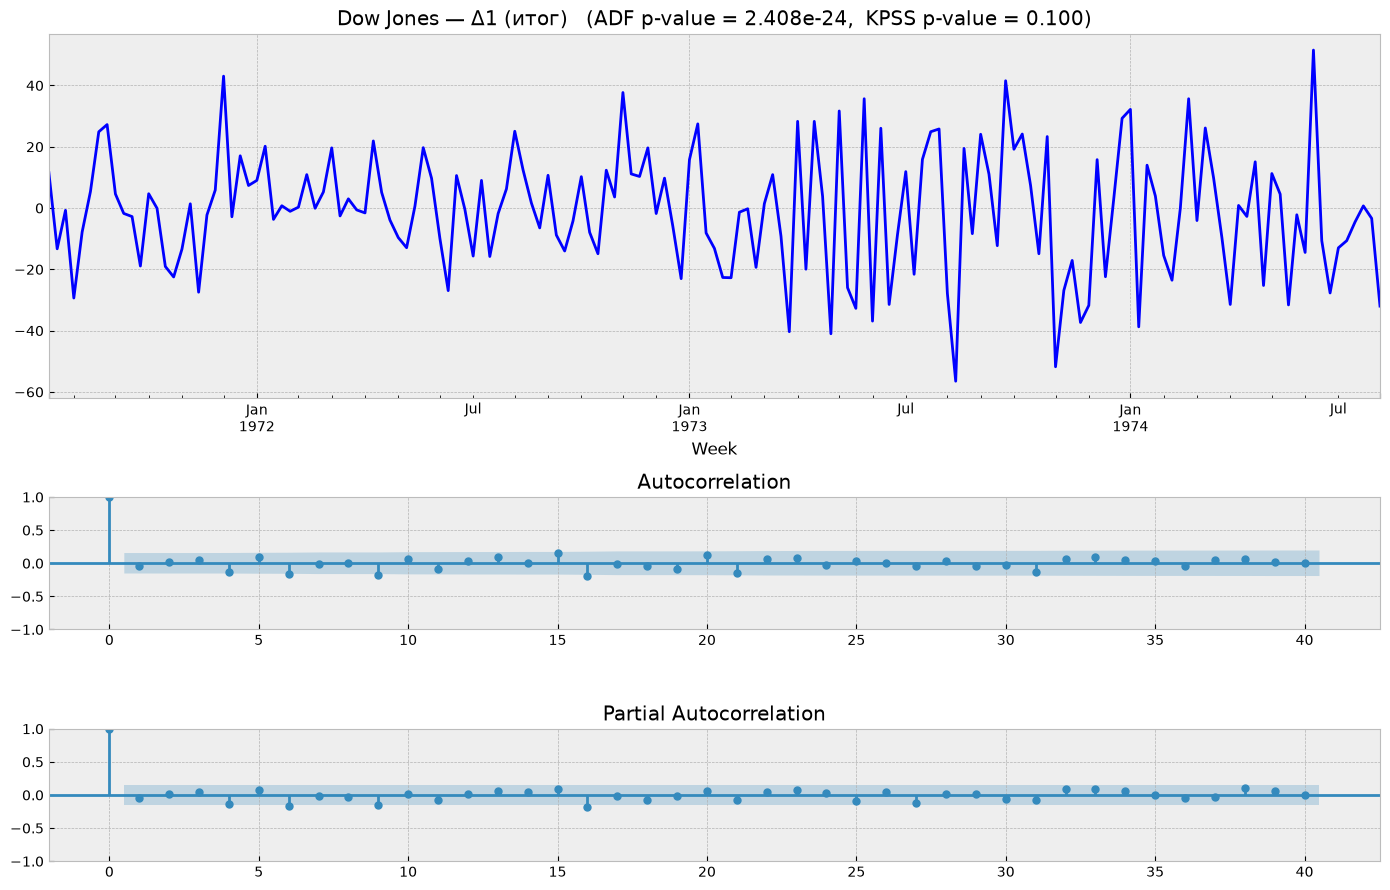

Тест Льюнга-Бокса (H0: автокорреляций нет):
      lb_stat  lb_pvalue
10  15.995823   0.099752
20  34.227316   0.024627


In [37]:
dowjones_stat = dowjones.diff(1).dropna()
dj_res = tsplot(dowjones_stat, lags=40, title='Dow Jones — Δ1 (итог)')
ljung_box(dowjones_stat);

**Итог по ряду 5.** `ADF p ≈ 2.4e-24`, `KPSS p > 0.1`. После одного дифференцирования ряд
превратился практически в белый шум: ACF и PACF целиком лежат внутри доверительного коридора
(редкие выходы на лагах 6, 9, 16 — ожидаемые ложные срабатывания при уровне значимости 5%
и 40 проверяемых лагах), тест Льюнга–Бокса гипотезу об отсутствии автокорреляции не отвергает.
Это подтверждает гипотезу эффективного рынка: приращения индекса непредсказуемы. Ряд стационарен.

In [38]:
remember('Weekly Dow-Jones closings', dj_raw_res, dowjones_stat, 'Δ1 (без Бокса-Кокса)');

---
# Ряд 6. Daily total female births in California

Ежедневное число рождений девочек в Калифорнии за 1959 год, 365 наблюдений.

### 6.1. Исходный ряд

Results of Dickey-Fuller Test:
Test Statistic                  -4.808291
p-value                          0.000052
#Lags Used                       6.000000
Number of Observations Used    358.000000
Critical Value (1%)             -3.448749
Critical Value (5%)             -2.869647
Critical Value (10%)            -2.571089

Results of KPSS Test:  statistic = 1.6130, p-value = 0.010 (обрезается в [0.01, 0.10])
Вывод: ADF -> стационарен;  KPSS -> НЕ стационарен


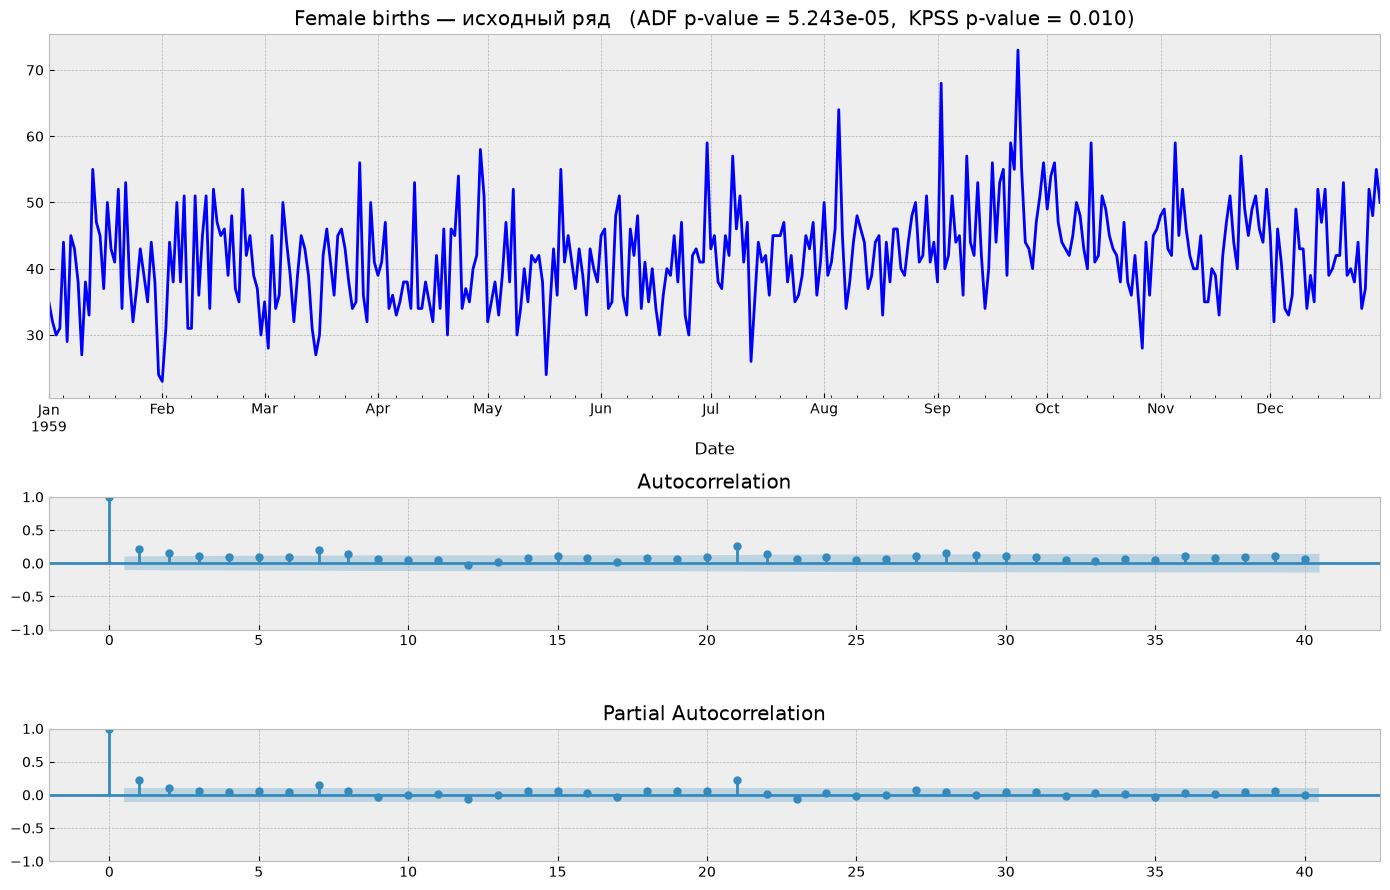

In [39]:
births_raw_res = tsplot(births, lags=40, title='Female births — исходный ряд')

**Что видим — и почему тесты расходятся.** Ряд выглядит почти как шум, и ADF даёт `p ≈ 5e-5`,
то есть единичного корня в нём нет. Но **KPSS даёт `p = 0.01` и отвергает стационарность**.
Противоречия тут нет: тесты проверяют разные вещи. Единичного корня (стохастического тренда)
действительно нет, но в ряде есть медленный детерминированный дрейф уровня — к концу года
рождений в среднем больше, чем в начале. Проверим это напрямую.

Линейный тренд: наклон = 0.0191 рождений/день (7.0 за год), p-value = 1.04e-07


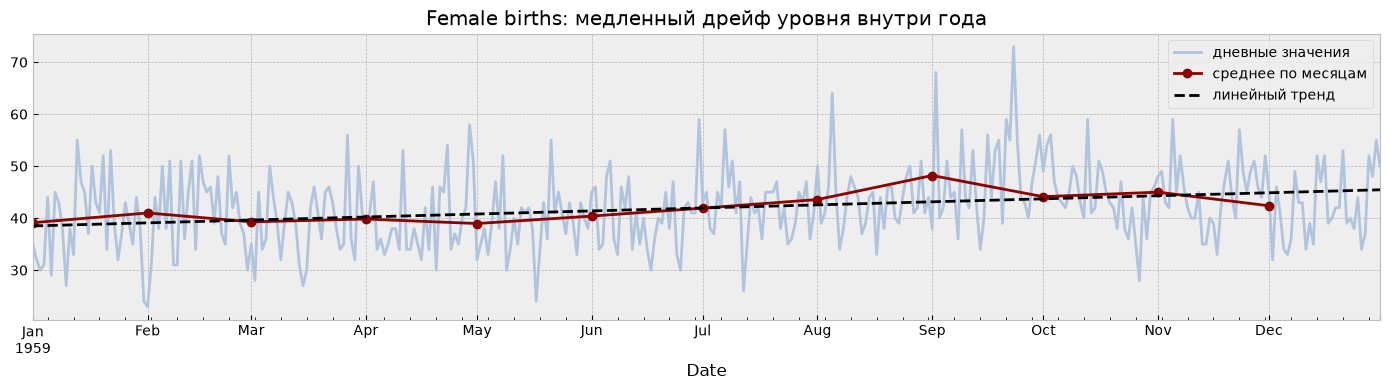

In [40]:
import scipy.stats as st

t = np.arange(len(births))
slope, intercept, r, p_trend, se = st.linregress(t, births.values)
print('Линейный тренд: наклон = %.4f рождений/день (%.1f за год), p-value = %.2e'
      % (slope, slope * 365, p_trend))

monthly_mean = births.resample('MS').mean()
with plt.style.context('bmh'):
    plt.figure(figsize=(14, 4))
    births.plot(color='lightsteelblue', label='дневные значения')
    monthly_mean.plot(color='darkred', marker='o', label='среднее по месяцам')
    plt.plot(births.index, intercept + slope * t, 'k--', label='линейный тренд')
    plt.legend(); plt.title('Female births: медленный дрейф уровня внутри года')
    plt.tight_layout(); plt.show()

Наклон значим — уровень действительно растёт примерно на 7 рождений в день за год.
Кроме того, на коррелограмме исходного ряда значимы лаги **7, 21, 28** — это **недельная
сезонность** (период 7): рождений в будни больше, чем в выходные. Посмотрим на недельный профиль.

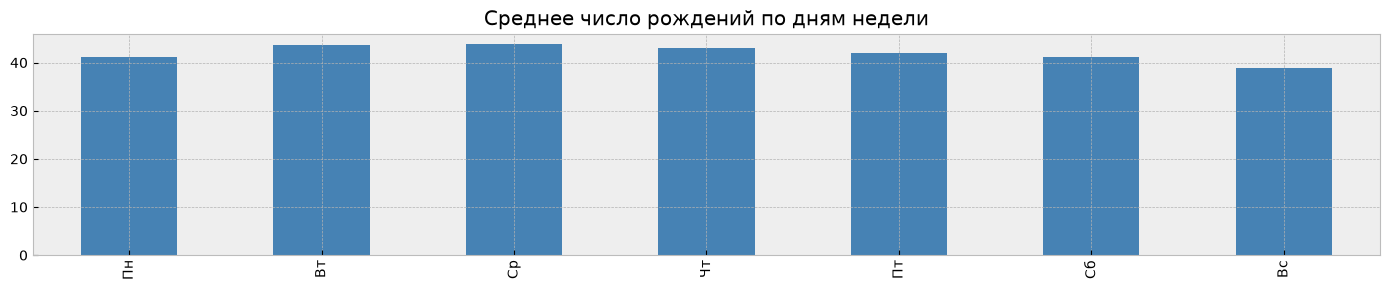

Пн    41.13
Вт    43.75
Ср    43.85
Чт    43.08
Пт    41.96
Сб    41.19
Вс    38.88


In [41]:
weekday_mean = births.groupby(births.index.dayofweek).mean()
weekday_mean.index = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
with plt.style.context('bmh'):
    plt.figure(figsize=(14, 3))
    weekday_mean.plot(kind='bar', color='steelblue')
    plt.title('Среднее число рождений по дням недели')
    plt.tight_layout(); plt.show()
print(weekday_mean.round(2).to_string())

Разница между будними днями и выходными хорошо заметна. Дисперсия по ходу года стабильна
(λ Бокса–Кокса ниже это подтвердит), поэтому ограничимся одним сезонным дифференцированием
с лагом 7: оно убирает и недельную сезонность, и линейный дрейф одновременно
(разность с лагом `s` уничтожает любой линейный тренд).

In [42]:
print('Оптимальное λ по Боксу-Коксу: %.3f' % boxcox_normmax(births.values))
half = len(births) // 2
print('std первой половины : %.2f' % births.iloc[:half].std())
print('std второй половины : %.2f' % births.iloc[half:].std())
print('=> дисперсия стабильна, стабилизирующее преобразование не требуется')

Оптимальное λ по Боксу-Коксу: 0.284
std первой половины : 7.03
std второй половины : 7.00
=> дисперсия стабильна, стабилизирующее преобразование не требуется


Results of Dickey-Fuller Test:
Test Statistic                -8.316786e+00
p-value                        3.662540e-13
#Lags Used                     1.400000e+01
Number of Observations Used    3.430000e+02
Critical Value (1%)           -3.449560e+00
Critical Value (5%)           -2.870004e+00
Critical Value (10%)          -2.571279e+00

Results of KPSS Test:  statistic = 0.0170, p-value = 0.100 (обрезается в [0.01, 0.10])
Вывод: ADF -> стационарен;  KPSS -> стационарен


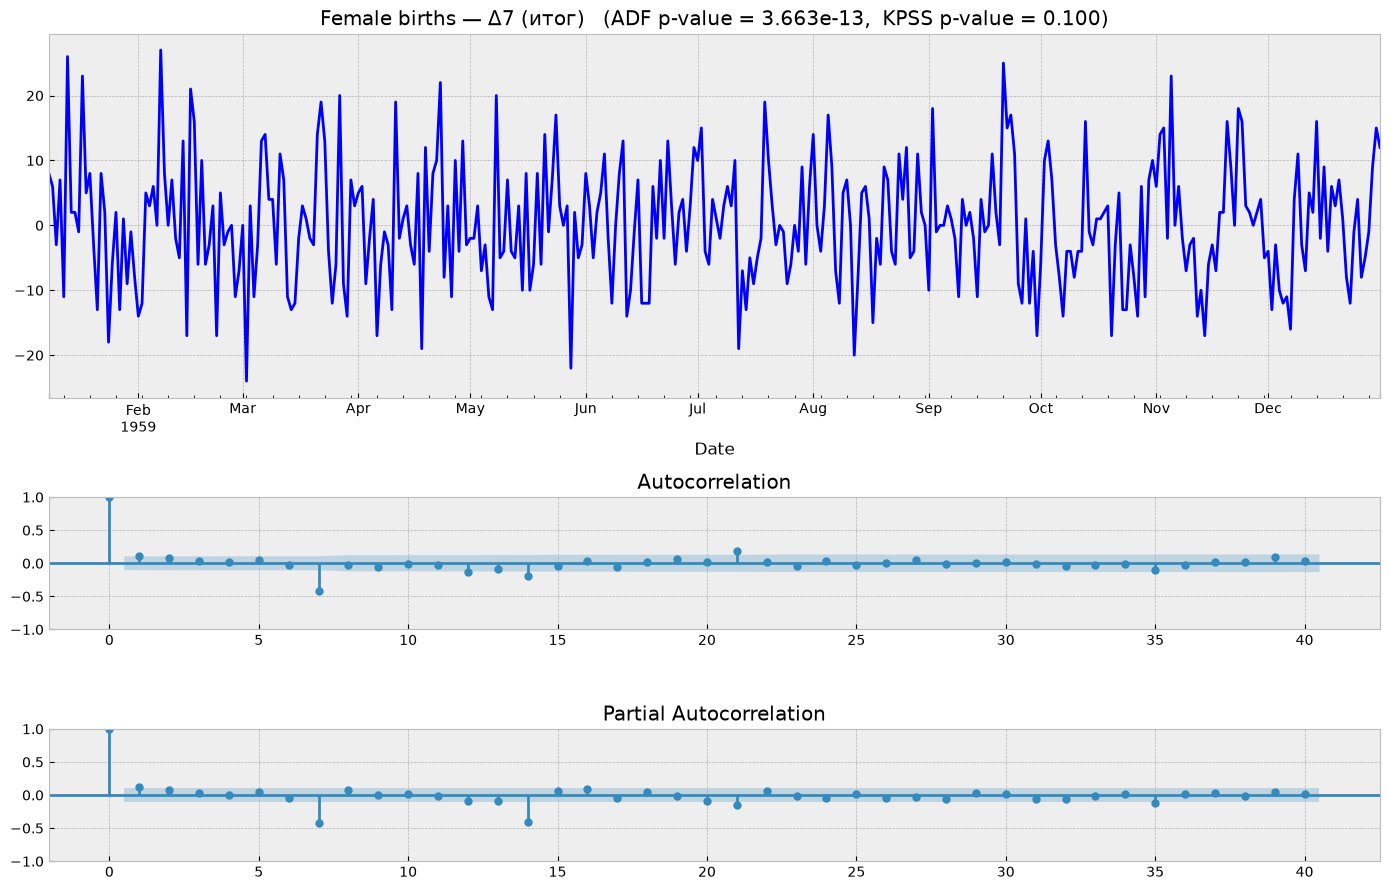

Тест Льюнга-Бокса (H0: автокорреляций нет):
       lb_stat     lb_pvalue
10   73.867919  7.898763e-12
20  100.195191  1.162242e-12


In [43]:
births_stat = births.diff(7).dropna()
births_res = tsplot(births_stat, lags=40, title='Female births — Δ7 (итог)')
ljung_box(births_stat);

In [44]:
wd = births_stat.groupby(births_stat.index.dayofweek).mean()
wd.index = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
print('Средние по дням недели после Δ7 (должны быть около нуля):')
print(wd.round(3).to_string())

Средние по дням недели после Δ7 (должны быть около нуля):
Пн    0.157
Вт    0.373
Ср    0.196
Чт    0.288
Пт    0.235
Сб    0.078
Вс    0.118


**Итог по ряду 6.** `ADF p ≈ 3.7e-13`, `KPSS p > 0.1` — теперь оба теста согласованно
подтверждают стационарность. Всплески на лагах 7, 21, 28 исчезли, средние по дням недели
обнулились, дрейф уровня ушёл. Значимый отрицательный лаг 7 — ожидаемая MA-компонента
сезонного дифференцирования. Ряд стационарен.

*Замечание.* Если ориентироваться только на тест Дики–Фуллера, этот ряд можно было бы счесть
стационарным «как есть» (`p ≈ 5e-5`). Это хорошая иллюстрация того, почему одного ADF
недостаточно: он не видит ни детерминированного тренда, ни сезонности.

In [45]:
remember('Daily total female births', births_raw_res, births_stat, 'Δ7 (без Бокса-Кокса)');

---
# Итоговая таблица

In [46]:
final = pd.DataFrame(list(results.values()))[
    ['Ряд', 'Преобразование', 'N (итог)',
     'ADF p (исходный)', 'ADF p (итог)', 'KPSS p (исходный)', 'KPSS p (итог)']
]
for col in ['ADF p (исходный)', 'ADF p (итог)']:
    final[col] = final[col].map(lambda v: '%.2e' % v)
for col in ['KPSS p (исходный)', 'KPSS p (итог)']:
    final[col] = final[col].map(lambda v: '%.2f' % v)
final

,Ряд,Преобразование,N (итог),ADF p (исходный),ADF p (итог),KPSS p (исходный),KPSS p (итог)
0,Monthly sales of company X,Box-Cox(λ=0) + Δ1 + Δ12,64,9.89e-01,1.67e-01,0.01,0.10
1,Monthly Boston armed robberies,Box-Cox(λ=0) + Δ1,117,9.94e-01,2.38e-11,0.01,0.10
2,International airline passengers,Box-Cox(λ=0) + Δ1 + Δ12,131,9.92e-01,2.49e-04,0.01,0.10
3,Mean monthly air temperature,Δ12 (без Бокса-Кокса и без Δ1),228,1.70e-02,1.14e-07,0.10,0.10
4,Weekly Dow-Jones closings,Δ1 (без Бокса-Кокса),161,6.22e-01,2.41e-24,0.02,0.10
5,Daily total female births,Δ7 (без Бокса-Кокса),358,5.24e-05,3.66e-13,0.01,0.10


### Сравнение исходных и приведённых к стационарности рядов

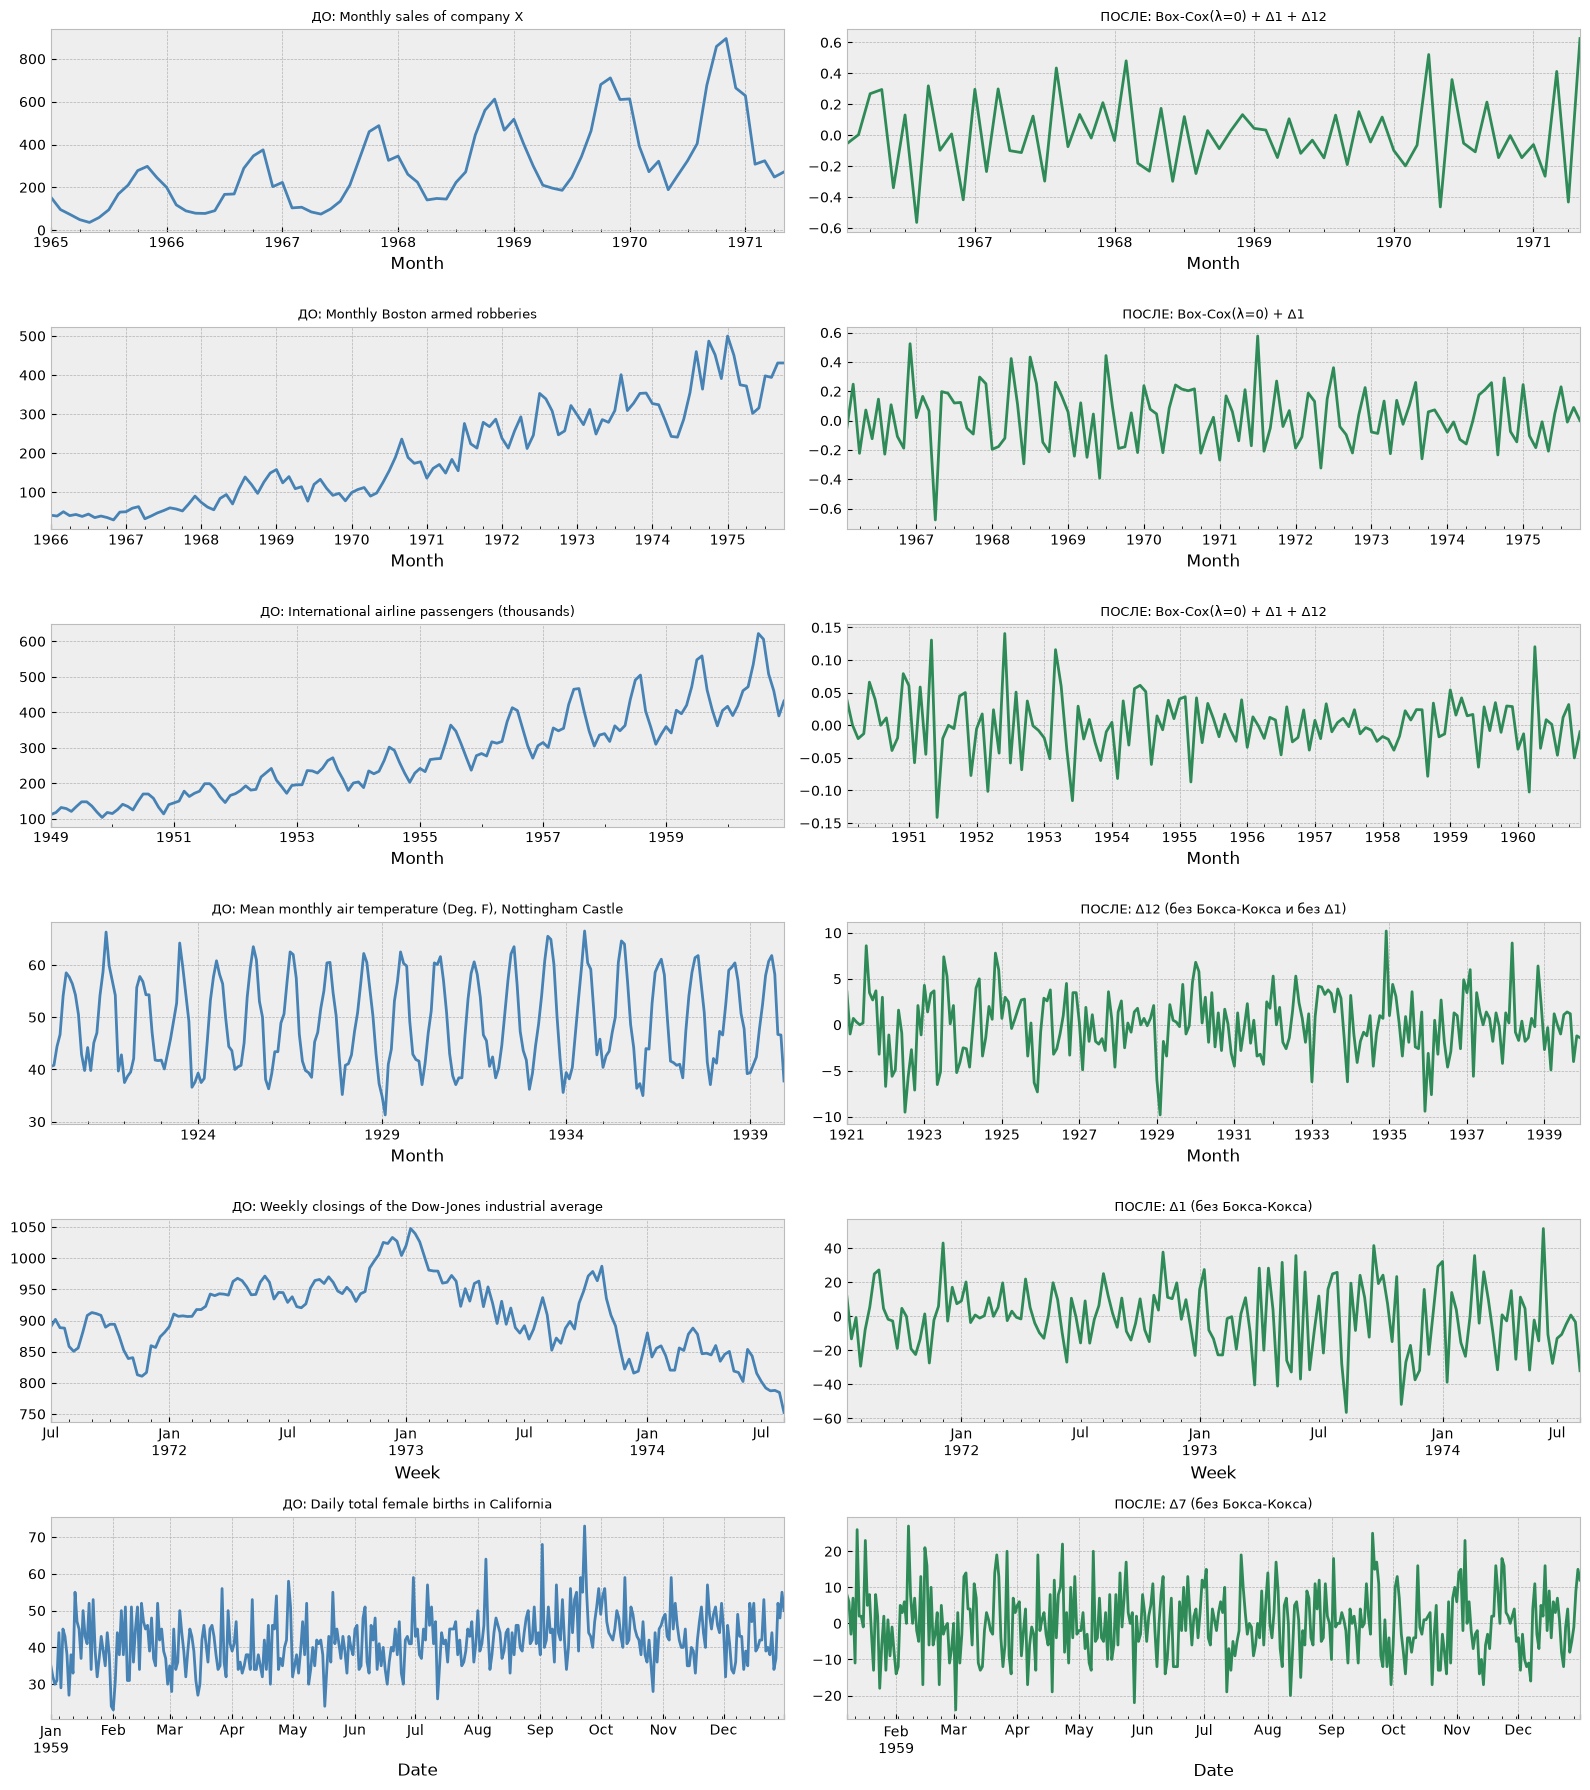

In [47]:
stationary_series = {
    'Monthly sales of company X': sales_stat,
    'Monthly Boston armed robberies': robberies_stat,
    'International airline passengers (thousands)': airline_stat,
    'Mean monthly air temperature (Deg. F), Nottingham Castle': temperature_stat,
    'Weekly closings of the Dow-Jones industrial average': dowjones_stat,
    'Daily total female births in California': births_stat,
}

with plt.style.context('bmh'):
    fig, axes = plt.subplots(6, 2, figsize=(16, 18))
    for i, key in enumerate(all_series):
        all_series[key].plot(ax=axes[i, 0], color='steelblue')
        axes[i, 0].set_title('ДО: %s' % key, fontsize=9)
        stationary_series[key].plot(ax=axes[i, 1], color='seagreen')
        axes[i, 1].set_title('ПОСЛЕ: %s' % results[list(results)[i]]['Преобразование'], fontsize=9)
    plt.tight_layout()
    plt.show()

### Проверка постоянства среднего и дисперсии «на глаз»

In [48]:
rows = []
for key, ts in stationary_series.items():
    parts = np.array_split(ts.values, 4)
    rows.append({
        'Ряд': key[:40],
        **{'mean Q%d' % (i + 1): round(float(np.mean(p)), 3) for i, p in enumerate(parts)},
        **{'std Q%d' % (i + 1): round(float(np.std(p)), 3) for i, p in enumerate(parts)},
    })
pd.DataFrame(rows).set_index('Ряд')

,mean Q1,mean Q2,mean Q3,mean Q4,std Q1,std Q2,std Q3,std Q4
Ряд,,,,,,,,
Monthly sales of company X,-0.019,0.020,-0.007,0.012,0.268,0.233,0.111,0.314
Monthly Boston armed robberies,0.032,0.017,0.016,0.014,0.246,0.204,0.205,0.158
International airline passengers (thousa,0.004,0.001,-0.006,0.002,0.061,0.049,0.021,0.042
"Mean monthly air temperature (Deg. F), N",0.144,0.002,0.304,-0.344,3.997,3.263,3.150,3.215
Weekly closings of the Dow-Jones industr,1.891,1.462,-0.978,-5.862,14.397,14.108,24.966,22.441
Daily total female births in California,0.211,0.489,0.494,-0.371,10.299,8.836,8.862,8.844


Средние по четвертям каждого ряда колеблются около нуля, стандартные отклонения внутри ряда
сопоставимы между собой — постоянство первых двух моментов выполняется.

---

# Выводы

Все шесть рядов приведены к стационарному виду. Применённые преобразования:

| № | Ряд | Проблемы исходного ряда | Преобразование |
|---|---|---|---|
| 1 | Monthly sales of company X | растущая дисперсия, тренд, годовая сезонность | `Box-Cox(λ=0) + Δ1 + Δ12` |
| 2 | Monthly Boston armed robberies | растущая дисперсия, сильный тренд | `Box-Cox(λ=0) + Δ1` |
| 3 | International airline passengers | мультипликативная сезонность, тренд | `Box-Cox(λ=0) + Δ1 + Δ12` |
| 4 | Mean monthly air temperature | только годовая сезонность | `Δ12` |
| 5 | Weekly Dow-Jones closings | случайное блуждание (единичный корень) | `Δ1` |
| 6 | Daily total female births | недельная сезонность + медленный дрейф | `Δ7` |

**Основные наблюдения.**

1. **Универсального рецепта нет.** Набор преобразований диктуется структурой конкретного ряда:
   температуре не нужны ни логарифм, ни `Δ1`, а Dow Jones обошёлся одним дифференцированием.
   Применять «log + Δ1 + Δ12» ко всему подряд — ошибка: лишние шаги ведут к передифференцированию
   (рост дисперсии и искусственные отрицательные выбросы в ACF), что было показано на ряде ограблений.

2. **Порядок шагов важен.** Сначала стабилизируем дисперсию (Бокс–Кокс), потом убираем тренд (`Δ1`),
   потом сезонность (`Δ_s`). Если сначала дифференцировать, мультипликативная сезонность останется
   неоднородной по амплитуде.

3. **Одного теста Дики–Фуллера недостаточно.** На ряде температуры ADF формально «отвергал
   нестационарность» при очевидной сезонности, а на ряде рождений не замечал детерминированного
   дрейфа. Связка ADF + KPSS + визуальный анализ коррелограмм даёт надёжную картину.

4. **ADF теряет мощность на коротких рядах.** На ряде продаж компании X после двух дифференцирований
   осталось 64 наблюдения, и автоподбор лагов по AIC «съел» мощность теста. KPSS, коррелограммы и
   ADF с умеренным числом лагов согласованно подтверждают стационарность.

5. **Остаточные значимые лаги 1 и s — это норма.** Отрицательные ACF на лаге 1 после `Δ1` и на лаге
   s после `Δ_s` — MA-компоненты, которые вносят сами операторы дифференцирования. Они не нарушают
   стационарность и как раз подсказывают порядок будущей SARIMA-модели.